<a href="https://colab.research.google.com/github/aymuos/starship/blob/main/fundamental_EDA/fc_all_city_ICP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Feature Creator - All Cities (LaDe Dataset)

**Cities:** Shanghai, Hangzhou, Chongqing  
**Target:** `eta_mins = (sign_time - receipt_time) / 60`  
**Author:** Soumya - Thesis: Causal-informed RL for ETA Prediction

---

## Pipeline Overview

```
load_delivery()
    add_euclidean_distance()
    add_batch_features()
    add_workload()  [event-sweep O(n log n)]
    GPS: load_gps_window() -> courier_snapshot() -> filter_stale_gps()
    DuckDB: compute_speed_percentile() + compute_trajectory_features()
    merge delivery + state + trajectory
    add_temporal_features()
    add_workload_dual_representation()   <- THREE parallel encodings
    add_delivery_tiers()                 <- per-city ETA tiers
    add_icp_environment_labels()         <- city x tier = 9 ICP envs
    add_gps_missingness_flag()
    add_typecode_encoding()
    add_spatial_congestion()
    add_weather()
    final_sanity_check()
```

## Workload Representation Strategy

Chongqing has batch loads up to 68 (vs ~35 for Shanghai/Hangzhou).  
A single representation cannot serve both causal analysis and RL:

| Column | Method | Use |
|---|---|---|
| `workload_capped` | Hard clip at 20 (global) | **ICP / PCMCI+** |
| `workload_pct_rank` | Rank / n, city-relative | **RL state space** |
| `workload_log` | log10(x+1) | **LightGBM baseline** |

## Phase 1 - Invariant Causal Prediction (ICP)

**Environments:** `city x delivery_tier` -> 9 groups  
**Method:** Linear ICP via Levene + Kruskal-Wallis residual tests at alpha=0.05  
**Output:** `invariant_features.json` -> input to Phase 2 (PCMCI+)


## 0. Install & Imports

In [3]:
!pip install duckdb polars pyarrow --quiet

In [39]:
import polars as pl
import duckdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import date
from scipy.special import ndtri
import os

pl.Config.set_tbl_rows(10)
print("Polars:", pl.__version__, " | DuckDB:", duckdb.__version__)


Polars: 1.35.2  | DuckDB: 1.3.2


## 1. Configuration

Edit the paths and parameters below before running.


In [5]:
# -- Paths --------------------------------------------------------------------
BASE         = "/content/drive/MyDrive/ml/PROCESSED/matched/city_divided/"
WEATHER_BASE = "/content/drive/MyDrive/ml/weather-outputs/"
OUTPUT_DIR   = "/content/drive/MyDrive/ml/PROCESSED/final/"
ICP_DIR      = "/content/drive/MyDrive/ml/PROCESSED/icp/"

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(ICP_DIR).mkdir(parents=True, exist_ok=True)

# -- Pipeline hyper-parameters ------------------------------------------------
PRE_MIN   = 15    # GPS look-back window (minutes)
MAX_GAP   = 30    # GPS staleness threshold (minutes)
GRID_SIZE = 500   # spatial grid cell size (affine units ~500 m)

# -- Workload representation parameters ---------------------------------------
GLOBAL_WORKLOAD_CAP = 20   # universal hard cap for ICP (all cities)
HIGH_LOAD_THRESH    = 10
OVERLOAD_THRESH     = 15

# -- ICP / causal parameters --------------------------------------------------
ICP_MIN_ENV_SAMPLES = 100   # min deliveries per environment for ICP
PCMCI_MIN_SAMPLES   = 200   # min per-courier observations for PCMCI+
ICP_ALPHA           = 0.05  # significance level for invariance tests

# -- ETA tier boundaries (per-city percentiles) -------------------------------
TIER_P_LOW  = 0.33   # smooth  -> [0,    P33]
TIER_P_MID  = 0.67   # normal  -> (P33,  P67]
TIER_P_HIGH = 0.95   # delayed -> (P67,  P95]  (above P95 stays 'delayed')

# -- City registry ------------------------------------------------------------
CITY_CONFIGS = [
    {
        "city_en"      : "Shanghai",
        "delivery_file": "shanghai_data.csv",
        "gps_file"     : "shanghai_delivery_data.parquet",
        "weather_file" : "shanghai_wsi_mar17_apr20_2021.csv",
        "holidays"     : ["2021-04-03", "2021-04-04", "2021-04-05"],
        "holiday_eve"  : "2021-04-02",
    },
    {
        "city_en"      : "Hangzhou",
        "delivery_file": "hangzhou_data.csv",
        "gps_file"     : "hangzhou_delivery_data.parquet",
        "weather_file" : "hangzhou_wsi_mar17_apr20_2021.csv",
        "holidays"     : ["2021-04-03", "2021-04-04", "2021-04-05"],
        "holiday_eve"  : "2021-04-02",
    },
    {
        "city_en"      : "Chongqing",
        "delivery_file": "chongqing_data.csv",
        "gps_file"     : "chongqing_delivery_data.parquet",
        "weather_file" : "chongqing_wsi_mar17_apr20_2021.csv",
        "holidays"     : ["2021-04-03", "2021-04-04", "2021-04-05"],
        "holiday_eve"  : "2021-04-02",
    },
]

# -- Feature sets -------------------------------------------------------------

# ICP / PCMCI+ -- uses globally-capped workload (same definition all cities)
ICP_FEATURES = [
    "order_id", "city", "delivery_tier", "environment",
    "workload_capped", "high_load", "overloaded",
    "batch_rank_capped", "late_batch", "extreme_batch", "batch_size",
    "speed_mean", "distance_travelled", "gps_points", "gps_gap_min",
    "is_trajectory_available", "pickup_destination_distance",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "is_holiday", "is_holiday_eve", "is_weekend", "delivery_sequence",
    "spatial_congestion_norm", "courier_local_load",
    "WSI", "precipitation", "temperature_2m", "windspeed_10m",
    "typecode_grouped_type 1", "typecode_grouped_type 2",
    "typecode_grouped_type 3",
    "eta_mins",
]

# RL state space -- uses city-relative workload (no info loss for Chongqing)
RL_FEATURES = [
    "order_id", "city", "delivery_tier", "environment",
    "workload_pct_rank", "workload_log", "workload_tier",
    "batch_rank_capped", "late_batch", "batch_size",
    "speed_mean", "distance_travelled", "gps_points",
    "is_trajectory_available", "pickup_destination_distance",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "is_holiday", "is_weekend", "delivery_sequence",
    "spatial_congestion_norm", "courier_local_load",
    "WSI", "precipitation", "typecode_cb",
    "eta_mins",
]

SELECTED_FEATURES = sorted(set(ICP_FEATURES + RL_FEATURES))


## 2. Pipeline Functions

All transformation logic lives here. Functions are stateless — they receive a
dataframe (and sometimes a DuckDB connection / path) and return a new dataframe.


### 2.1 `load_delivery` — Load and normalise the delivery CSV

In [6]:
def load_delivery(csv_path: str) -> pl.DataFrame:
    """
    Load the city delivery CSV, parse datetimes, drop redundant columns,
    rename the target variable, and sort for downstream ASOF joins.

    Returns
    -------
    pl.DataFrame  sorted by (delivery_user_id, receipt_time)
    """
    df = (
        pl.read_csv(csv_path)
        .with_columns([
            pl.col("receipt_time").str.to_datetime("%Y-%m-%d %H:%M:%S"),
            pl.col("sign_time").str.to_datetime("%Y-%m-%d %H:%M:%S"),
        ])
        .drop(["sign_lat", "sign_lng"])          # redundant destination cols
        .rename({"horizon_ETA": "eta_mins"})     # canonical target name
        .with_columns(pl.col("delivery_user_id").cast(pl.Utf8))
        .sort(["delivery_user_id", "receipt_time"])
    )
    print(f"  Loaded {df.height:,} deliveries | {df['delivery_user_id'].n_unique()} couriers")
    return df


### 2.2 `load_gps_window` — Fetch relevant GPS records via DuckDB

In [7]:
def load_gps_window(
    con: duckdb.DuckDBPyConnection,
    gps_path: str,
    couriers: list,
    start_time,
    end_time,
    pre_min: int = PRE_MIN,
) -> pl.DataFrame:
    """
    Pull GPS rows for the relevant couriers and time range from parquet.
    Uses DuckDB for push-down filtering — avoids loading the full GPS file.

    Returns
    -------
    pl.DataFrame  columns: delivery_user_id, gps_time, lat, lng
                  sorted by (delivery_user_id, gps_time)
    """
    # DuckDB requires a tuple with ≥2 elements for the IN clause
    couriers_tuple = tuple(couriers) if len(couriers) > 1 else (couriers[0], couriers[0])

    gps_df = con.execute(f"""
        SELECT postman_id, gps_time, lat, lng
        FROM parquet_scan('{gps_path}')
        WHERE postman_id IN {couriers_tuple}
          AND gps_time BETWEEN
              TIMESTAMP '{start_time}' - INTERVAL '{pre_min} minutes'
              AND TIMESTAMP '{end_time}'
    """).pl()

    gps_df = (
        gps_df
        .rename({"postman_id": "delivery_user_id"})
        .sort(["delivery_user_id", "gps_time"])
    )
    print(f"  GPS rows loaded: {gps_df.height:,}")
    return gps_df


### 2.3 `courier_snapshot` + `filter_stale_gps` — Last known position

In [8]:
def courier_snapshot(delivery: pl.DataFrame, gps_df: pl.DataFrame) -> pl.DataFrame:
    """
    ASOF backward join: attach the courier's most recent GPS point.
    """
    # Ensure both sides of the join have explicit sorted flags
    delivery = delivery.with_columns([
        pl.col("delivery_user_id").set_sorted(),
        pl.col("receipt_time").set_sorted()
    ])

    gps_df = gps_df.with_columns([
        pl.col("delivery_user_id").set_sorted(),
        pl.col("gps_time").set_sorted()
    ])

    state = delivery.join_asof(
        gps_df,
        left_on="receipt_time",
        right_on="gps_time",
        by="delivery_user_id",
        strategy="backward",
    ).rename({"lat": "last_x", "lng": "last_y", "gps_time": "last_gps_time"})

    state = state.with_columns(
        (pl.col("receipt_time") - pl.col("last_gps_time"))
        .dt.total_minutes()
        .alias("gps_gap_min")
    )
    return state

def filter_stale_gps(state: pl.DataFrame, max_gap: int = MAX_GAP) -> pl.DataFrame:
    """
    Invalidate GPS matches older than max_gap minutes.
    """
    state = state.with_columns(
        pl.when(pl.col("gps_gap_min") <= max_gap)
          .then(pl.col("gps_gap_min"))
          .otherwise(None)
          .alias("gps_gap_min")
    )
    state = state.with_columns([
        pl.when(pl.col("gps_gap_min").is_null()).then(None).otherwise(pl.col("last_x")).alias("last_x"),
        pl.when(pl.col("gps_gap_min").is_null()).then(None).otherwise(pl.col("last_y")).alias("last_y"),
    ])

    total   = state.height
    missing = state["gps_gap_min"].null_count()
    print(f"  GPS coverage after {max_gap}-min filter: "
          f"{total - missing:,}/{total:,} ({(total-missing)/total*100:.1f}%)")
    return state

### 2.4 `compute_speed_percentile` — 99th-percentile speed cap

In [9]:
def compute_speed_percentile(
    con: duckdb.DuckDBPyConnection,
    gps_path: str,
    percentile: float = 0.99,
) -> float:
    """
    Compute a robust speed cap from the full GPS parquet.

    Filters:
      dt > 5 s    — removes GPS duplicates (sampling ≈ 20 s)
      dt < 600 s  — removes long gaps that create phantom distance
      dist < 10000 — removes privacy-related coordinate jumps

    Returns
    -------
    float  speed threshold in affine coordinate units / second
    """
    speed_q = con.execute(f"""
        WITH motion AS (
            SELECT
                SQRT(POWER(lat - LAG(lat) OVER w, 2) +
                     POWER(lng - LAG(lng) OVER w, 2)) AS dist,
                EXTRACT(EPOCH FROM (gps_time - LAG(gps_time) OVER w)) AS dt
            FROM parquet_scan('{gps_path}')
            WINDOW w AS (PARTITION BY postman_id ORDER BY gps_time)
        ),
        clean AS (
            SELECT dist / dt AS speed
            FROM motion
            WHERE dt > 5 AND dt < 600 AND dist < 10000
        )
        SELECT quantile_cont(speed, {percentile}) FROM clean
    """).fetchone()[0]

    print(f"  Speed {percentile*100:.0f}th percentile cap: {speed_q:.4f} units/s")
    return speed_q


### 2.5 `compute_trajectory_features` — 15-min pre-delivery GPS window

In [10]:
def compute_trajectory_features(
    con: duckdb.DuckDBPyConnection,
    gps_path: str,
    speed_cap: float,
    pre_min: int = PRE_MIN,
) -> pl.DataFrame:
    """
    For each order, aggregate GPS segments in [receipt_time - pre_min, receipt_time].

    Speed filtering (applied to each segment):
      dt ≤ 1 s     — GPS duplicate / noise
      dist > 5000  — privacy jump (affine coordinate teleportation)
      dist/dt > speed_cap — physically impossible speed (99th-pct threshold)

    Returns
    -------
    pl.DataFrame  columns: order_id, gps_points, speed_mean, distance_travelled
    """
    traj = con.execute(f"""
        WITH gps_window AS (
            SELECT
                d.order_id,
                g.gps_time, g.lat, g.lng,
                LAG(g.lat)      OVER (PARTITION BY d.order_id ORDER BY g.gps_time) AS prev_lat,
                LAG(g.lng)      OVER (PARTITION BY d.order_id ORDER BY g.gps_time) AS prev_lng,
                LAG(g.gps_time) OVER (PARTITION BY d.order_id ORDER BY g.gps_time) AS prev_time
            FROM delivery_tbl d
            JOIN parquet_scan('{gps_path}') g
              ON g.postman_id = d.delivery_user_id
            WHERE g.gps_time BETWEEN
                d.receipt_time - INTERVAL '{pre_min} minutes'
                AND d.receipt_time
        ),
        motion AS (
            SELECT
                order_id,
                SQRT(POWER(lat - prev_lat, 2) + POWER(lng - prev_lng, 2)) AS dist,
                EXTRACT(EPOCH FROM (gps_time - prev_time)) AS dt
            FROM gps_window
        ),
        speed_calc AS (
            SELECT
                order_id, dist, dt,
                CASE
                    WHEN dt IS NULL       THEN NULL   -- first row in window
                    WHEN dt <= 1          THEN NULL   -- GPS duplicate / noise
                    WHEN dist > 5000      THEN NULL   -- privacy coord jump
                    WHEN dist / dt > {speed_cap} THEN NULL  -- speed cap
                    ELSE dist / dt
                END AS speed
            FROM motion
        )
        SELECT
            order_id,
            COUNT(*)        AS gps_points,
            AVG(speed)      AS speed_mean,
            SUM(dist)       AS distance_travelled
        FROM speed_calc
        GROUP BY order_id
    """).pl()

    print(f"  Trajectory features computed for {traj.height:,} orders")
    return traj


### 2.6 `add_euclidean_distance` — Pickup → destination distance

In [11]:
def add_euclidean_distance(delivery: pl.DataFrame) -> pl.DataFrame:
    """
    Euclidean distance between pickup (receipt) and destination (POI)
    in the affine coordinate space (≈ metres at ~1e6 scale).

    Adds column: pickup_destination_distance
    """
    return delivery.with_columns(
        ((pl.col("receipt_lng") - pl.col("poi_lng")).pow(2) +
         (pl.col("receipt_lat") - pl.col("poi_lat")).pow(2)).sqrt()
        .alias("pickup_destination_distance")
    )


### 2.7 `add_batch_features` — Batch size and intra-batch rank

In [12]:
def add_batch_features(delivery: pl.DataFrame) -> pl.DataFrame:
    """
    Compute batch_size and batch_rank for simultaneous dispatcher pushes.

    Batch = set of orders sharing the same (delivery_user_id, receipt_time).
    order_id is the tiebreaker when multiple orders arrive at the exact same
    timestamp — this is critical for deterministic, reproducible ranks.

    Adds columns: batch_size, batch_rank
    """
    delivery = delivery.sort(["delivery_user_id", "receipt_time", "order_id"])

    delivery = delivery.with_columns(
        pl.len().over(["delivery_user_id", "receipt_time"]).alias("batch_size")
    )
    delivery = delivery.with_columns(
        pl.int_range(0, pl.len())
          .over(["delivery_user_id", "receipt_time"])
          .alias("batch_rank")
    )
    n_batched = delivery.filter(pl.col("batch_size") > 1).height
    print(f"  Orders in multi-order batches: {n_batched:,} "
          f"| max batch_size: {delivery['batch_size'].max()}")
    return delivery


### 2.8 `add_workload` — Concurrent active orders (event-sweep)

In [13]:
def add_workload(delivery: pl.DataFrame) -> pl.DataFrame:
    """
    Compute active_orders_at_receipt_time via a linear-time event-sweep
    algorithm (O(n log n) sort + O(n) scan).
    """
    # Explicitly sort and set sorted flags for both 'by' and 'on' columns
    delivery = (
        delivery
        .sort(["delivery_user_id", "receipt_time"])
        .with_columns([
            pl.col("delivery_user_id").set_sorted(),
            pl.col("receipt_time").set_sorted()
        ])
    )

    start_events = delivery.select([
        "delivery_user_id",
        pl.col("receipt_time").alias("time"),
        pl.lit(1).alias("delta"),
        pl.lit(1).alias("priority"),
    ])
    end_events = delivery.select([
        "delivery_user_id",
        pl.col("sign_time").alias("time"),
        pl.lit(-1).alias("delta"),
        pl.lit(0).alias("priority"),
    ])

    events = (
        pl.concat([start_events, end_events])
        .sort(["delivery_user_id", "time", "priority"])
        .with_columns([
            pl.col("delivery_user_id").set_sorted(),
            pl.col("time").set_sorted(),
            pl.col("delta").cum_sum().over("delivery_user_id").alias("active_orders")
        ])
    )

    # The flags now prevent the 'Sortedness' warning naturally
    workload = delivery.join_asof(
        events.select(["delivery_user_id", "time", "active_orders"]),
        left_on="receipt_time",
        right_on="time",
        by="delivery_user_id",
        strategy="backward",
    )

    workload = workload.with_columns(
        (pl.col("active_orders") - 1).clip(lower_bound=0)
        .alias("active_orders_at_receipt_time")
    )

    print(f"  Workload | mean: {workload['active_orders_at_receipt_time'].mean():.2f} "
          f"| max: {workload['active_orders_at_receipt_time'].max()}")
    return workload

### 2.9 `add_temporal_features` — Cyclical time + calendar flags

In [14]:
def add_temporal_features(
    features: pl.DataFrame,
    holidays: list,
    holiday_eve: str,
) -> pl.DataFrame:
    """
    Adds time-of-day and calendar context features.

    Cyclical encoding preserves the circular topology of time:
        sin/cos(2π × hour / 24) — avoids the 23→0 discontinuity.

    Adds columns:
        hour, weekday, day_of_week
        hour_sin, hour_cos, day_sin, day_cos
        is_weekend, is_holiday, is_holiday_eve
        delivery_sequence  (cumulative per courier — fatigue proxy)
    """
    features = features.with_columns([
        pl.col("receipt_time").dt.hour().alias("hour"),
        pl.col("receipt_time").dt.weekday().alias("weekday"),
        pl.col("receipt_time").dt.weekday().alias("day_of_week"),
    ])

    features = features.with_columns([
        (2 * np.pi * pl.col("hour")    / 24).sin().alias("hour_sin"),
        (2 * np.pi * pl.col("hour")    / 24).cos().alias("hour_cos"),
        (2 * np.pi * pl.col("weekday") / 7 ).sin().alias("day_sin"),
        (2 * np.pi * pl.col("weekday") / 7 ).cos().alias("day_cos"),
    ])

    features = features.with_columns([
        # Polars weekday: Mon=1 … Sun=7
        (pl.col("weekday") >= 6).cast(pl.Int8).alias("is_weekend"),
        pl.col("receipt_time").dt.date().cast(pl.Utf8)
          .is_in(holidays).cast(pl.Int8).alias("is_holiday"),
        (pl.col("receipt_time").dt.date().cast(pl.Utf8) == holiday_eve)
          .cast(pl.Int8).alias("is_holiday_eve"),
    ])

    features = features.with_columns(
        pl.col("order_id").cum_count().over("delivery_user_id")
          .alias("delivery_sequence")
    )
    return features


### 2.10 `add_workload_dual_representation` — Three parallel workload encodings

Produces three representations from `active_orders_at_receipt_time`:

**Rep 1 — Global consistent** (`workload_capped`, cap=20) for ICP/PCMCI+.  
Same definition in all cities so invariance tests are valid.  
M/G/1 saturation inflection is at ~15 orders in all three cities.

**Rep 2 — City-relative** (`workload_pct_rank`, `workload_tier`) for RL.  
P80 in Chongqing = same relative stress as P80 in Shanghai.  
No information above cap=20 is discarded.

**Rep 3 — Log-compressed** (`workload_log`) for LightGBM/neural baselines.  
log10(x+1) compresses the Chongqing tail (20->68) without arbitrary cutoff.

In [15]:
def add_workload_dual_representation(
    features: pl.DataFrame,
    city_en: str,
    global_cap: int           = GLOBAL_WORKLOAD_CAP,
    high_load_thresh: int     = HIGH_LOAD_THRESH,
    overload_thresh: int      = OVERLOAD_THRESH,
    rank_cap: int             = 15,
    late_batch_thresh: int    = 8,
    extreme_batch_thresh: int = 12,
) -> pl.DataFrame:
    """
    Three parallel workload representations for different modelling goals.

    Rep 1 - Global consistent (for ICP / PCMCI+)
        workload_capped   : clip at global_cap (same meaning in ALL cities)
        high_load         : binary > high_load_thresh
        overloaded        : binary > overload_thresh

        Rationale: ICP tests coefficient invariance across environments.
        If the feature definition changes per city the test is invalid.
        The M/G/1 saturation inflection is at ~15 orders in all three cities,
        so cap=20 preserves the operationally meaningful signal.

    Rep 2 - City-relative (for RL state space)
        workload_pct_rank : rank / n in [0,1] (continuous percentile position)
        workload_tier     : ordinal 0-3 based on within-city P50/P75/P90

        Rationale: Chongqing workload=40 is the same relative stress as
        Shanghai workload=18. The RL policy transfers across cities without
        scale mismatch, and NO information above cap=20 is discarded.

    Rep 3 - Log-compressed (for LightGBM / neural baselines)
        workload_log : log10(active_orders + 1)

        Rationale: Tree splits on raw counts waste depth on the long tail
        (20 -> 68 in Chongqing). Log compression makes each unit increase
        equally informative across the full range.

    Batch non-linear indicators (shared across all representations):
        batch_rank_capped, late_batch, extreme_batch
    """
    raw = pl.col("active_orders_at_receipt_time")

    # Rep 1: Global hard cap
    features = features.with_columns([
        raw.clip(upper_bound=global_cap).alias("workload_capped"),
        (raw > high_load_thresh).cast(pl.Int8).alias("high_load"),
        (raw > overload_thresh).cast(pl.Int8).alias("overloaded"),
    ])

    # Rep 2: City-relative percentile
    p50 = features["active_orders_at_receipt_time"].quantile(0.50)
    p75 = features["active_orders_at_receipt_time"].quantile(0.75)
    p90 = features["active_orders_at_receipt_time"].quantile(0.90)
    p95 = features["active_orders_at_receipt_time"].quantile(0.95)
    p99 = features["active_orders_at_receipt_time"].quantile(0.99)

    features = features.with_columns([
        (raw.rank() / raw.len()).alias("workload_pct_rank"),
        pl.when(raw <= p50).then(pl.lit(0))
          .when(raw <= p75).then(pl.lit(1))
          .when(raw <= p90).then(pl.lit(2))
          .otherwise(pl.lit(3))
          .cast(pl.Int8).alias("workload_tier"),
    ])

    # Rep 3: Log-compressed
    features = features.with_columns(
        (raw + 1).log(base=10).alias("workload_log")
    )

    # Batch non-linear indicators
    features = features.with_columns([
        pl.col("batch_rank").clip(upper_bound=rank_cap).alias("batch_rank_capped"),
        (pl.col("batch_rank") > late_batch_thresh).cast(pl.Int8).alias("late_batch"),
        (pl.col("batch_rank") > extreme_batch_thresh).cast(pl.Int8).alias("extreme_batch"),
    ])

    # Diagnostics
    wmax    = features["active_orders_at_receipt_time"].max()
    n_above = features.filter(raw > global_cap).height
    n_total = features.height
    print(f"  {city_en} workload | P50={p50:.0f} P75={p75:.0f} P90={p90:.0f} "
          f"P95={p95:.0f} P99={p99:.0f} max={wmax:.0f}")
    print(f"    Above global cap ({global_cap}): "
          f"{n_above:,}/{n_total:,} ({n_above/n_total*100:.1f}%)")
    print(f"    workload_pct_rank range: "
          f"[{features['workload_pct_rank'].min():.3f}, "
          f"{features['workload_pct_rank'].max():.3f}]")
    return features


### 2.11 `add_delivery_tiers` — Per-city ETA tier segmentation

Cuts `eta_mins` at within-city P33/P67 into `smooth / normal / delayed`.
These tiers are the second dimension of the ICP environment label.
Values above P95 stay in 'delayed' to avoid tiny environment sample sizes.

In [16]:
def add_delivery_tiers(features: pl.DataFrame, city_en: str) -> pl.DataFrame:
    """
    Segment deliveries into per-city ETA tiers using within-city percentiles.

    Boundaries are computed on the FULL eta_mins range.
    Values above P95 stay in 'delayed' -- extreme outliers do not get a
    separate tier to avoid tiny environment sample sizes in ICP.

    Adds columns:
        eta_p33, eta_p67, eta_p95  -- city thresholds stored per row
        delivery_tier              -- 'smooth' | 'normal' | 'delayed'
    """
    p33 = float(features["eta_mins"].quantile(TIER_P_LOW))
    p67 = float(features["eta_mins"].quantile(TIER_P_MID))
    p95 = float(features["eta_mins"].quantile(TIER_P_HIGH))

    features = features.with_columns([
        pl.lit(p33).alias("eta_p33"),
        pl.lit(p67).alias("eta_p67"),
        pl.lit(p95).alias("eta_p95"),
        pl.when(pl.col("eta_mins") <= p33).then(pl.lit("smooth"))
          .when(pl.col("eta_mins") <= p67).then(pl.lit("normal"))
          .otherwise(pl.lit("delayed"))
          .alias("delivery_tier"),
    ])

    counts = features.group_by("delivery_tier").len().sort("delivery_tier").to_dicts()
    print(f"  {city_en} ETA tiers | P33={p33:.1f}  P67={p67:.1f}  P95={p95:.1f} mins")
    print(f"    Tier counts: {counts}")
    return features


### 2.12 `add_icp_environment_labels` — ICP environment identifiers

Creates `environment = city + '_' + delivery_tier`  
(e.g. `Shanghai_smooth`, `Chongqing_delayed`).  
Up to 9 environments across 3 cities x 3 tiers.  
`environment_id` is an integer encoding for statsmodels/sklearn.

In [17]:
def add_icp_environment_labels(features: pl.DataFrame) -> pl.DataFrame:
    """
    Compose the ICP environment label from city + delivery_tier.

    environment = city x tier  ->  up to 9 environments across 3 cities x 3 tiers.
    e.g. 'Shanghai_smooth', 'Chongqing_delayed'

    Adds columns:
        environment     -- string label
        environment_id  -- integer encoding (sorted alphabetically, for sklearn)
    """
    features = features.with_columns(
        (pl.col("city") + pl.lit("_") + pl.col("delivery_tier"))
        .alias("environment")
    )
    envs    = sorted(features["environment"].unique().to_list())
    env_map = {e: i for i, e in enumerate(envs)}

    features = features.with_columns(
        pl.col("environment")
          .map_elements(lambda x: env_map[x], return_dtype=pl.Int32)
          .alias("environment_id")
    )

    print(f"  ICP environments ({len(envs)}):")
    for e in envs:
        n    = features.filter(pl.col("environment") == e).height
        flag = "OK" if n >= ICP_MIN_ENV_SAMPLES else "WARN: BELOW THRESHOLD"
        print(f"    {e:<32} {n:>6,} deliveries  {flag}")
    return features


### 2.13 `add_gps_missingness_flag` — Structural fill + indicator

In [18]:
def add_gps_missingness_flag(features: pl.DataFrame) -> pl.DataFrame:
    """
    Encode GPS absence as a first-class operational state.

    Strategy: structural fill (0) + binary indicator, NOT statistical imputation.
    Rationale: missing GPS ≠ stationary courier. It correlates with indoor
    deliveries, dense urban canyons, and device quality — structurally different
    from observed zero-speed movement.

    Diagnostic: ρ(workload, is_trajectory_available) ≈ 0.03 (HZ) / -0.07 (SH)
    — near-zero confirms the two signals are independent.

    Adds columns:
        is_trajectory_available  (0/1)
        fills speed_mean, distance_travelled, gps_points with 0 where null
    """
    features = features.with_columns(
        pl.col("speed_mean").is_not_null().cast(pl.Int8).alias("is_trajectory_available")
    )
    features = features.with_columns([
        pl.col("speed_mean").fill_null(0),
        pl.col("distance_travelled").fill_null(0),
        pl.col("gps_points").fill_null(0),
    ])

    corr = features.select(
        pl.corr("active_orders_at_receipt_time", "is_trajectory_available").alias("rho")
    ).item()
    print(f"  ρ(workload, GPS available) = {corr:.4f}  "
          f"[near-zero ✓ → independent signals]")
    return features


### 2.14 `add_typecode_encoding` — OHE grouping + frequency encoding

In [19]:
def add_typecode_encoding(features: pl.DataFrame, top_n: int = 3) -> pl.DataFrame:
    """
    Dual encoding for the package type field.

    (a) OHE grouping — top_n codes → named groups; rest → 'rare'.
        One-hot encoded → binary columns for causal graph root nodes.
    (b) Frequency encoding — each code replaced by its count in the dataset.
        Dense ordinal signal for tree models and bandit policies.

    Adds columns:
        typecode_grouped          (categorical: 'type 1', 'type 2', 'type 3', 'rare')
        typecode_grouped_type 1   (binary OHE)
        typecode_grouped_type 2   (binary OHE)
        typecode_grouped_type 3   (binary OHE)
        typecode_cb               (frequency encoding)
    """
    # (a) Group
    top_codes = (
        features.select(pl.col("typecode").value_counts(sort=True))
        .unnest("typecode")
        .head(top_n)
        .get_column("typecode")
        .to_list()
    )
    mapping = {code: f"type {i+1}" for i, code in enumerate(top_codes)}

    features = features.with_columns(
        pl.col("typecode")
          .map_elements(lambda x: mapping.get(x, "rare"), return_dtype=pl.Utf8)
          .alias("typecode_grouped")
    )

    # OHE for top_n groups (exclude 'rare' as baseline)
    for i in range(1, top_n + 1):
        label = f"type {i}"
        features = features.with_columns(
            (pl.col("typecode_grouped") == label).cast(pl.Int8).alias(f"typecode_grouped_{label}")
        )

    # (b) Frequency encode
    freq = (
        features.group_by("typecode").len().rename({"len": "typecode_cb"})
    )
    features = features.join(freq, on="typecode", how="left")
    features = features.with_columns(pl.col("typecode_cb").fill_null(0))

    print(f"  typecode groups: {features['typecode_grouped'].value_counts().sort('typecode_grouped')}")
    return features


### 2.15 `add_spatial_congestion` — Grid-based SCI + courier local load

In [20]:
def add_spatial_congestion(
    features: pl.DataFrame,
    grid_size: int = GRID_SIZE,
) -> pl.DataFrame:
    """
    Spatial Congestion Index (SCI) — adapted from Ke et al. (SIGKDD 2017).

    SCI(g, t) = number of deliveries in grid cell g during hour t.
    Tessellates the affine coordinate space into grid_size-unit cells.

    courier_local_load = delivery count per (courier, hour) — finer congestion.
    spatial_congestion_norm = z-score of SCI (makes it model-ready).

    Adds columns:
        grid_x, grid_y                — cell coordinates
        time_window                   — receipt_time truncated to hour
        spatial_congestion_index      — raw count
        spatial_congestion_norm       — z-score
        courier_local_load            — per-courier hourly count
    """
    features = features.with_columns([
        (pl.col("receipt_lng") // grid_size).alias("grid_x"),
        (pl.col("receipt_lat") // grid_size).alias("grid_y"),
        pl.col("receipt_time").dt.truncate("1h").alias("time_window"),
    ])

    sci = (
        features.group_by(["grid_x", "grid_y", "time_window"])
        .len().rename({"len": "spatial_congestion_index"})
    )
    features = features.join(sci, on=["grid_x", "grid_y", "time_window"], how="left")

    cll = (
        features.group_by(["delivery_user_id", "time_window"])
        .len().rename({"len": "courier_local_load"})
    )
    features = features.join(cll, on=["delivery_user_id", "time_window"], how="left")

    sci_mean = features["spatial_congestion_index"].mean()
    sci_std  = features["spatial_congestion_index"].std()
    features = features.with_columns(
        ((pl.col("spatial_congestion_index") - sci_mean) / sci_std)
        .alias("spatial_congestion_norm")
    )
    print(f"  SCI | mean: {sci_mean:.2f} | std: {sci_std:.2f} "
          f"| max: {features['spatial_congestion_index'].max()}")
    return features


### 2.16 `add_weather` — Temporal ASOF join with hourly weather

In [21]:
def add_weather(
    features: pl.DataFrame,
    weather_csv: str,
    city_en: str,
) -> pl.DataFrame:
    """
    Join hourly weather observations to deliveries via ASOF backward join.
    Matches each receipt_time to the most recent prior weather record.

    Weather source: Open-Meteo hourly data (temperature, precipitation,
    wind speed, weather code, custom WSI composite).

    Adds columns (from weather CSV):
        temperature_2m, precipitation, windspeed_10m,
        WSI, norm_weathercode_sev
    """
    weather = (
        pl.read_csv(weather_csv)
        .with_columns(
            pl.col("datetime").str.strptime(pl.Datetime, strict=False).alias("weather_time")
        )
        .drop("datetime")
        .filter(pl.col("city") == city_en)
        .drop("city")  # Fix: Drop 'city' before join to avoid 'city_right' duplication
        .sort("weather_time")
    )

    features = features.sort("receipt_time")
    features = features.join_asof(
        weather,
        left_on="receipt_time",
        right_on="weather_time",
        strategy="backward",
    )

    pct_null = features["WSI"].null_count() / features.height * 100
    print(f"  Weather joined | WSI null: {pct_null:.1f}%")
    return features

### 2.17 `final_sanity_check` — Validation gates

In [22]:
def final_sanity_check(features: pl.DataFrame, city_en: str) -> None:
    """
    Six-gate validation. Raises AssertionError on failure so the pipeline
    stops rather than silently saving a corrupt features file.
    """
    print(f"\n{'-'*60}")
    print(f"  Sanity check: {city_en}")
    print(f"{'-'*60}")

    # 1. No null targets
    null_eta = features["eta_mins"].null_count()
    assert null_eta == 0, f"FAIL: {null_eta} null eta_mins!"
    print(f"  OK  eta_mins nulls: 0")

    # 2. Row uniqueness
    assert features.height == features["order_id"].n_unique(), \
        "FAIL: duplicate order_id rows!"
    print(f"  OK  Rows == unique order_ids: {features.height:,}")

    # 3. No accidental join duplicates
    dup_cols = [c for c in features.columns if c.endswith("_right")]
    assert not dup_cols, f"FAIL: duplicate columns found: {dup_cols}"
    print(f"  OK  No duplicate columns")

    # 4. Tier completeness
    if "delivery_tier" in features.columns:
        null_tier = features["delivery_tier"].null_count()
        assert null_tier == 0, f"FAIL: {null_tier} null delivery_tier!"
        print(f"  OK  delivery_tier nulls: 0")

    # 5. ICP environment sample sizes
    if "environment" in features.columns:
        low = (features.group_by("environment").len()
               .filter(pl.col("len") < ICP_MIN_ENV_SAMPLES))
        if low.height > 0:
            print(f"  WARN  Environments below {ICP_MIN_ENV_SAMPLES} samples:")
            print(low)
        else:
            print(f"  OK  All environments >= {ICP_MIN_ENV_SAMPLES} samples")

    # 6. Key feature null counts
    key_cols = [
        "active_orders_at_receipt_time", "workload_capped",
        "workload_pct_rank", "workload_log", "batch_rank", "hour_sin", "WSI",
    ]
    for col in key_cols:
        if col in features.columns:
            n = features[col].null_count()
            flag = "OK" if n == 0 else "WARN"
            print(f"  {flag}  {col} nulls: {n}")

    print(f"  Columns : {len(features.columns)}  |  Rows : {features.height:,}")
    print(f"{'-'*60}\n")


## 3. EDA / Diagnostic Functions

Quick visual diagnostics per city. Call these after `build_city_features()`
or from the cross-city comparison section.


In [23]:
def plot_speed_ccdf(con, gps_path: str, city_en: str) -> None:
    """
    Log-log CCDF of courier speed.
    A heavy right tail confirms the trajectory captures real inter-zone movement.
    A sharp drop-off at the far end = rare cross-city reallocation events.
    """
    speed_df = con.execute(f"""
        WITH motion AS (
            SELECT
                SQRT(POWER(lat - LAG(lat) OVER w, 2) +
                     POWER(lng - LAG(lng) OVER w, 2)) AS dist,
                EXTRACT(EPOCH FROM (gps_time - LAG(gps_time) OVER w)) AS dt
            FROM parquet_scan('{gps_path}')
            WINDOW w AS (PARTITION BY postman_id ORDER BY gps_time)
        )
        SELECT dist / dt AS speed
        FROM motion
        WHERE dt > 0 AND dist IS NOT NULL AND dist / dt IS NOT NULL
    """).pl().sort("speed")

    n = speed_df.height
    ccdf = speed_df.with_row_index("rank").with_columns(
        (1 - pl.col("rank") / n).alias("ccdf")
    )
    s = ccdf["speed"].to_numpy()
    p = ccdf["ccdf"].to_numpy()
    mask = (s > 0) & (p > 0)

    plt.figure(figsize=(6, 4))
    plt.loglog(s[mask], p[mask])
    plt.xlabel("Speed (log scale)")
    plt.ylabel("P(Speed ≥ v) (log scale)")
    plt.title(f"Courier Speed CCDF — {city_en}")
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_workload_saturation(features: pl.DataFrame, city_en: str) -> None:
    """
    Bar chart: mean ETA vs active orders (clipped at 20).
    Illustrates M/G/1 saturation curve — delay explodes near ρ→1.
    """
    plot_df = (
        features
        .with_columns(pl.col("active_orders_at_receipt_time").clip(upper_bound=20))
        .group_by("active_orders_at_receipt_time")
        .agg(pl.mean("eta_mins").alias("mean_eta"), pl.len().alias("n"))
        .sort("active_orders_at_receipt_time")
        .to_pandas()
    )
    plt.figure(figsize=(11, 4))
    sns.barplot(x="active_orders_at_receipt_time", y="mean_eta",
                data=plot_df, palette="viridis",
                hue="active_orders_at_receipt_time", legend=False)
    plt.axvline(x=14.5, color="red", linestyle="--", alpha=0.7, label="Saturation threshold")
    plt.title(f"Workload Saturation Curve — {city_en}")
    plt.xlabel("Active Orders at Receipt Time (clipped at 20)")
    plt.ylabel("Mean ETA (mins)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_batch_rank_eta(features: pl.DataFrame, city_en: str) -> None:
    """
    Line chart: mean ETA vs batch rank (clipped at 15).
    Monotonic rise validates the late_batch binary feature.
    """
    plot_df = (
        features
        .with_columns(pl.col("batch_rank").clip(upper_bound=15))
        .group_by("batch_rank")
        .agg(pl.mean("eta_mins").alias("mean_eta"), pl.len().alias("n"))
        .sort("batch_rank")
        .to_pandas()
    )
    plt.figure(figsize=(9, 4))
    plt.plot(plot_df["batch_rank"], plot_df["mean_eta"], marker="o")
    plt.fill_between(plot_df["batch_rank"],
                     plot_df["mean_eta"] * 0.9, plot_df["mean_eta"] * 1.1,
                     alpha=0.15)
    plt.axvline(x=8, color="orange", linestyle="--", alpha=0.7, label="late_batch threshold")
    plt.title(f"Batch Rank vs Mean ETA — {city_en}")
    plt.xlabel("Batch Rank (clipped at 15)")
    plt.ylabel("Mean ETA (mins)")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_eta_distribution(features: pl.DataFrame, city_en: str, clip_pct: float = 0.95) -> None:
    """
    KDE of eta_mins clipped at the 95th percentile to suppress extreme outliers.
    """
    cap = features["eta_mins"].quantile(clip_pct)
    data = features.filter(pl.col("eta_mins") <= cap)["eta_mins"].to_numpy()
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data, fill=True)
    plt.axvline(data.mean(), color="red",  linestyle="--", label=f"Mean {data.mean():.0f}")
    plt.axvline(float(np.median(data)), color="green", linestyle="--",
                label=f"Median {float(np.median(data)):.0f}")
    plt.title(f"ETA Distribution (≤P{int(clip_pct*100)}) — {city_en}")
    plt.xlabel("ETA (mins)")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_correlation_table(features: pl.DataFrame, city_en: str) -> None:
    """
    Key Pearson correlations with eta_mins.
    """
    targets = [
        "workload_capped", "active_orders_at_receipt_time",
        "batch_rank", "batch_rank_capped",
        "speed_mean", "gps_gap_min",
        "pickup_destination_distance", "spatial_congestion_norm",
        "WSI", "hour_sin",
    ]
    rows = []
    for col in targets:
        if col in features.columns:
            rho = features.select(pl.corr(col, "eta_mins")).item()
            rows.append((col, f"{rho:+.4f}"))
    print(f"\nPearson ρ with eta_mins — {city_en}")
    print(f"{'Feature':<38} {'ρ':>8}")
    print("─" * 48)
    for feat, rho in sorted(rows, key=lambda x: abs(float(x[1])), reverse=True):
        print(f"  {feat:<36} {rho:>8}")


## 4. Master Pipeline Function

`build_city_features` orchestrates all steps for a single city config dict.


In [24]:
def build_city_features(
    cfg: dict,
    base: str         = BASE,
    weather_base: str = WEATHER_BASE,
    pre_min: int      = PRE_MIN,
    max_gap: int      = MAX_GAP,
    grid_size: int    = GRID_SIZE,
    run_eda_plots: bool = True,
) -> pl.DataFrame:
    """
    End-to-end feature pipeline for one city.

    Steps
    -----
     1  load_delivery
     2  add_euclidean_distance
     3  add_batch_features
     4  add_workload  (event-sweep O(n log n))
     5  GPS window + courier_snapshot + filter_stale_gps
     6  compute_speed_percentile + compute_trajectory_features (DuckDB)
     7  merge delivery + state + trajectory
     8  add_temporal_features
     9  add_workload_dual_representation   <- 3 parallel encodings
    10  add_delivery_tiers                <- per-city ETA tiers
    11  add_icp_environment_labels        <- city x tier environments
    12  add_gps_missingness_flag
    13  add_typecode_encoding
    14  add_spatial_congestion
    15  add_weather
    16  city label + final_sanity_check
    """
    city_en  = cfg["city_en"]
    gps_path = base + cfg["gps_file"]

    print(f"\n{'='*60}")
    print(f"  Processing: {city_en}")
    print(f"{'='*60}")

    print("\n[1/12] Loading delivery data...")
    delivery = load_delivery(base + cfg["delivery_file"])

    print("[2/12] Computing pickup-destination distance...")
    delivery = add_euclidean_distance(delivery)

    print("[3/12] Computing batch features...")
    delivery = add_batch_features(delivery)

    print("[4/12] Computing courier workload (event sweep)...")
    delivery = add_workload(delivery)

    print("[5/12] Building GPS window & courier snapshot...")
    con        = duckdb.connect()
    couriers   = delivery["delivery_user_id"].unique().to_list()
    start_time = delivery["receipt_time"].min()
    end_time   = delivery["receipt_time"].max()

    gps_df = load_gps_window(con, gps_path, couriers, start_time, end_time, pre_min)
    state  = courier_snapshot(delivery, gps_df)
    state  = filter_stale_gps(state, max_gap)

    print("[6/12] Extracting trajectory features (DuckDB)...")
    con.register("delivery_tbl", delivery.to_pandas())
    speed_cap     = compute_speed_percentile(con, gps_path)
    traj_features = compute_trajectory_features(con, gps_path, speed_cap, pre_min)

    print("[7/12] Merging feature tables...")
    features = (
        delivery
        .join(state.select(["order_id", "last_x", "last_y", "gps_gap_min"]),
              on="order_id", how="left")
        .join(traj_features, on="order_id", how="left")
    )

    print("[8/12] Adding temporal & calendar features...")
    features = add_temporal_features(features, cfg["holidays"], cfg["holiday_eve"])

    print("[9/12] Adding dual workload representations...")
    # city label needed by add_icp_environment_labels -- add early
    features = features.with_columns(pl.lit(city_en).alias("city"))
    features = add_workload_dual_representation(features, city_en)

    print("[10/12] Computing per-city ETA delivery tiers...")
    features = add_delivery_tiers(features, city_en)

    print("[11/12] Adding ICP environment labels...")
    features = add_icp_environment_labels(features)

    features = add_gps_missingness_flag(features)
    features = add_typecode_encoding(features)
    features = add_spatial_congestion(features, grid_size)
    features = add_weather(features, weather_base + cfg["weather_file"], city_en)

    print("[12/12] Validating...")
    final_sanity_check(features, city_en)

    if run_eda_plots:
        print(f"\n--- EDA: {city_en} ---")
        plot_eta_distribution(features, city_en)
        plot_speed_ccdf(con, gps_path, city_en)
        plot_workload_saturation(features, city_en)
        plot_batch_rank_eta(features, city_en)
        print_correlation_table(features, city_en)

    con.close()
    return features


In [25]:
# -- Pipeline Orchestration: Process All Cities --------------------------------
city_results = {}

for cfg in CITY_CONFIGS:
    features = build_city_features(
        cfg,
        base=BASE,
        weather_base=WEATHER_BASE,
        pre_min=PRE_MIN,
        max_gap=MAX_GAP,
        grid_size=GRID_SIZE,
        run_eda_plots=False,  # Set to False for faster batch processing
    )
    city_results[cfg['city_en']] = features

print('\n✅ All cities processed. city_results is now ready for concatenation.')
# Display summary of rows processed
for city, df in city_results.items():
    print(f'  {city}: {df.height:,} rows')


  Processing: Shanghai

[1/12] Loading delivery data...
  Loaded 34,735 deliveries | 142 couriers
[2/12] Computing pickup-destination distance...
[3/12] Computing batch features...
  Orders in multi-order batches: 29,154 | max batch_size: 18
[4/12] Computing courier workload (event sweep)...


/tmp/ipykernel_854/2721316850.py:40: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  workload = delivery.join_asof(


  Workload | mean: 7.00 | max: 30
[5/12] Building GPS window & courier snapshot...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  GPS rows loaded: 1,636,158


...

  Speed 99th percentile cap: 12.2246 units/s


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  Trajectory features computed for 17,010 orders
[7/12] Merging feature tables...
[8/12] Adding temporal & calendar features...
[9/12] Adding dual workload representations...
  Chongqing workload | P50=8 P75=13 P90=21 P95=28 P99=57 max=68
    Above global cap (20): 2,843/26,670 (10.7%)
    workload_pct_rank range: [0.011, 1.000]
[10/12] Computing per-city ETA delivery tiers...
  Chongqing ETA tiers | P33=91.0  P67=196.0  P95=725.0 mins
    Tier counts: [{'delivery_tier': 'delayed', 'len': 8800}, {'delivery_tier': 'normal', 'len': 9007}, {'delivery_tier': 'smooth', 'len': 8863}]
[11/12] Adding ICP environment labels...
  ICP environments (3):
    Chongqing_delayed                 8,800 deliveries  OK
    Chongqing_normal                  9,007 deliveries  OK
    Chongqing_smooth                  8,863 deliveries  OK
  ρ(workload, GPS available) = -0.0663  [near-zero ✓ → independent signals]
  typecode groups: shape: (5, 2)
┌──────────────────┬───────┐
│ typecode_grouped ┆ count │
│ --- 

/tmp/ipykernel_854/1678867792.py:21: PolarsInefficientMapWarning: 
Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("environment").map_elements(lambda x: ...)
with this one instead:
  + pl.col("environment").replace_strict(env_map)

  .map_elements(lambda x: env_map[x], return_dtype=pl.Int32)


  Weather joined | WSI null: 0.0%
[12/12] Validating...

------------------------------------------------------------
  Sanity check: Chongqing
------------------------------------------------------------
  OK  eta_mins nulls: 0
  OK  Rows == unique order_ids: 26,670
  OK  No duplicate columns
  OK  delivery_tier nulls: 0
  OK  All environments >= 100 samples
  OK  active_orders_at_receipt_time nulls: 0
  OK  workload_capped nulls: 0
  OK  workload_pct_rank nulls: 0
  OK  workload_log nulls: 0
  OK  batch_rank nulls: 0
  OK  hour_sin nulls: 0
  OK  WSI nulls: 0
  Columns : 76  |  Rows : 26,670
------------------------------------------------------------


✅ All cities processed. city_results is now ready for concatenation.
  Shanghai: 34,735 rows
  Hangzhou: 40,744 rows
  Chongqing: 26,670 rows


In [28]:
# -- Schema-aligned combined parquets -----------------------------------------
# pl.concat(how='diagonal') silently fills missing OHE columns with null.
# We explicitly align to the union schema for reproducibility.

import os

all_dfs  = list(city_results.values())
all_cols = []
seen = set()
for df in all_dfs:
    for c in df.columns:
        if c not in seen:
            all_cols.append(c)
            seen.add(c)

aligned = []
for df in all_dfs:
    missing = [c for c in all_cols if c not in df.columns]
    if missing:
        df = df.with_columns([pl.lit(None).alias(c) for c in missing])
    aligned.append(df.select(all_cols))

combined      = pl.concat(aligned)
combined_path = os.path.join(OUTPUT_DIR, "all_cities_combined.parquet")
combined.write_parquet(combined_path)
print(f"Combined : {combined.height:,} rows x {combined.width} cols -> {combined_path}")

# ICP-ready combined (only ICP_FEATURES, all 3 cities)
icp_cols      = [c for c in ICP_FEATURES if c in combined.columns]
icp_combined  = combined.select(icp_cols)
icp_combined_path = os.path.join(ICP_DIR, "all_cities_icp_combined.parquet")
icp_combined.write_parquet(icp_combined_path)
print(f"ICP comb : {icp_combined.height:,} rows x {icp_combined.width} cols -> {icp_combined_path}")

print("\nEnvironment breakdown:")
print(
    combined.group_by(["city", "delivery_tier", "environment"])
    .len().sort(["city", "delivery_tier"])
    .rename({"len": "n_deliveries"})
)

Combined : 102,149 rows x 76 cols -> /content/drive/MyDrive/ml/PROCESSED/final/all_cities_combined.parquet
ICP comb : 102,149 rows x 35 cols -> /content/drive/MyDrive/ml/PROCESSED/icp/all_cities_icp_combined.parquet

Environment breakdown:
shape: (9, 4)
┌───────────┬───────────────┬───────────────────┬──────────────┐
│ city      ┆ delivery_tier ┆ environment       ┆ n_deliveries │
│ ---       ┆ ---           ┆ ---               ┆ ---          │
│ str       ┆ str           ┆ str               ┆ u32          │
╞═══════════╪═══════════════╪═══════════════════╪══════════════╡
│ Chongqing ┆ delayed       ┆ Chongqing_delayed ┆ 8800         │
│ Chongqing ┆ normal        ┆ Chongqing_normal  ┆ 9007         │
│ Chongqing ┆ smooth        ┆ Chongqing_smooth  ┆ 8863         │
│ Hangzhou  ┆ delayed       ┆ Hangzhou_delayed  ┆ 13385        │
│ Hangzhou  ┆ normal        ┆ Hangzhou_normal   ┆ 13836        │
│ Hangzhou  ┆ smooth        ┆ Hangzhou_smooth   ┆ 13523        │
│ Shanghai  ┆ delayed       ┆ S

## 7. Cross-City EDA

Overlay plots comparing all three cities — useful for thesis figures.


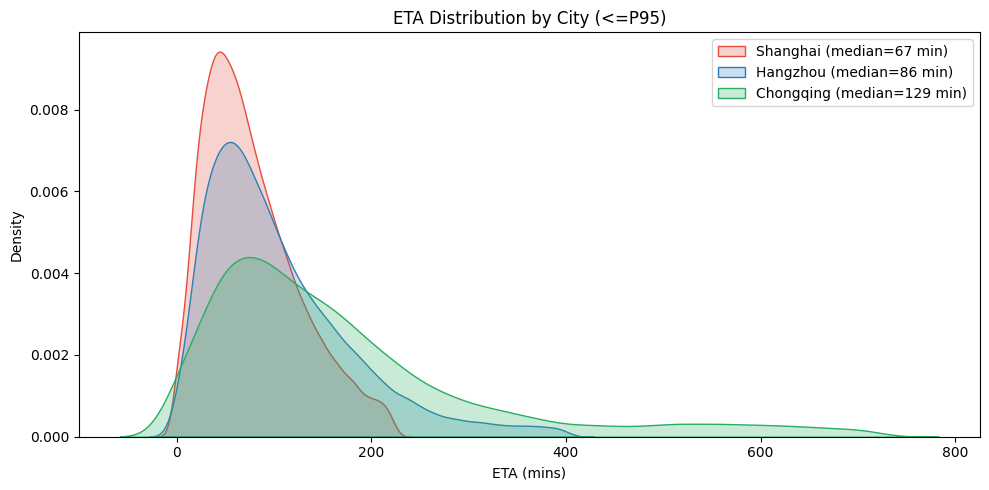

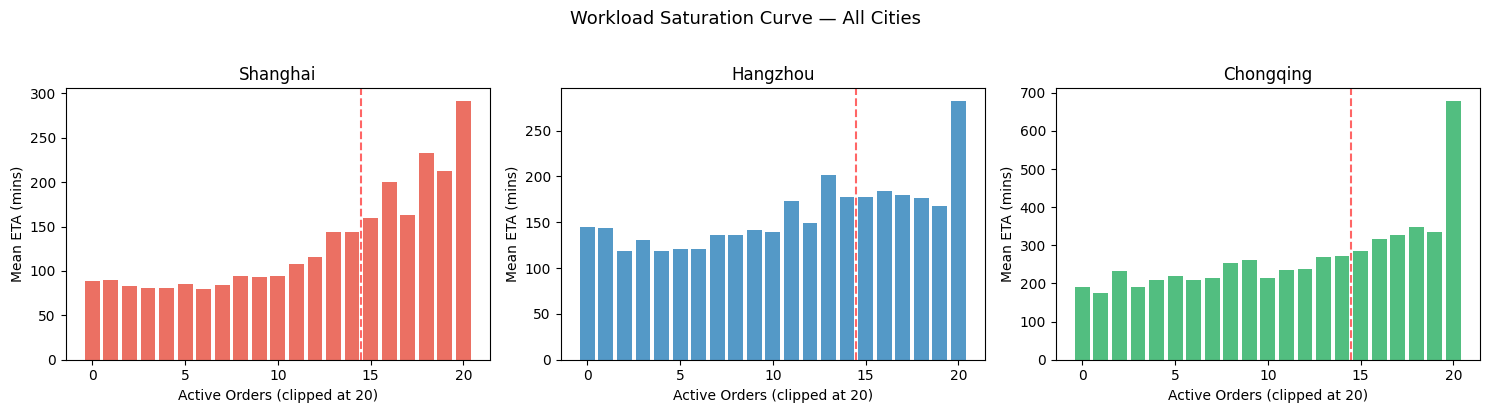

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


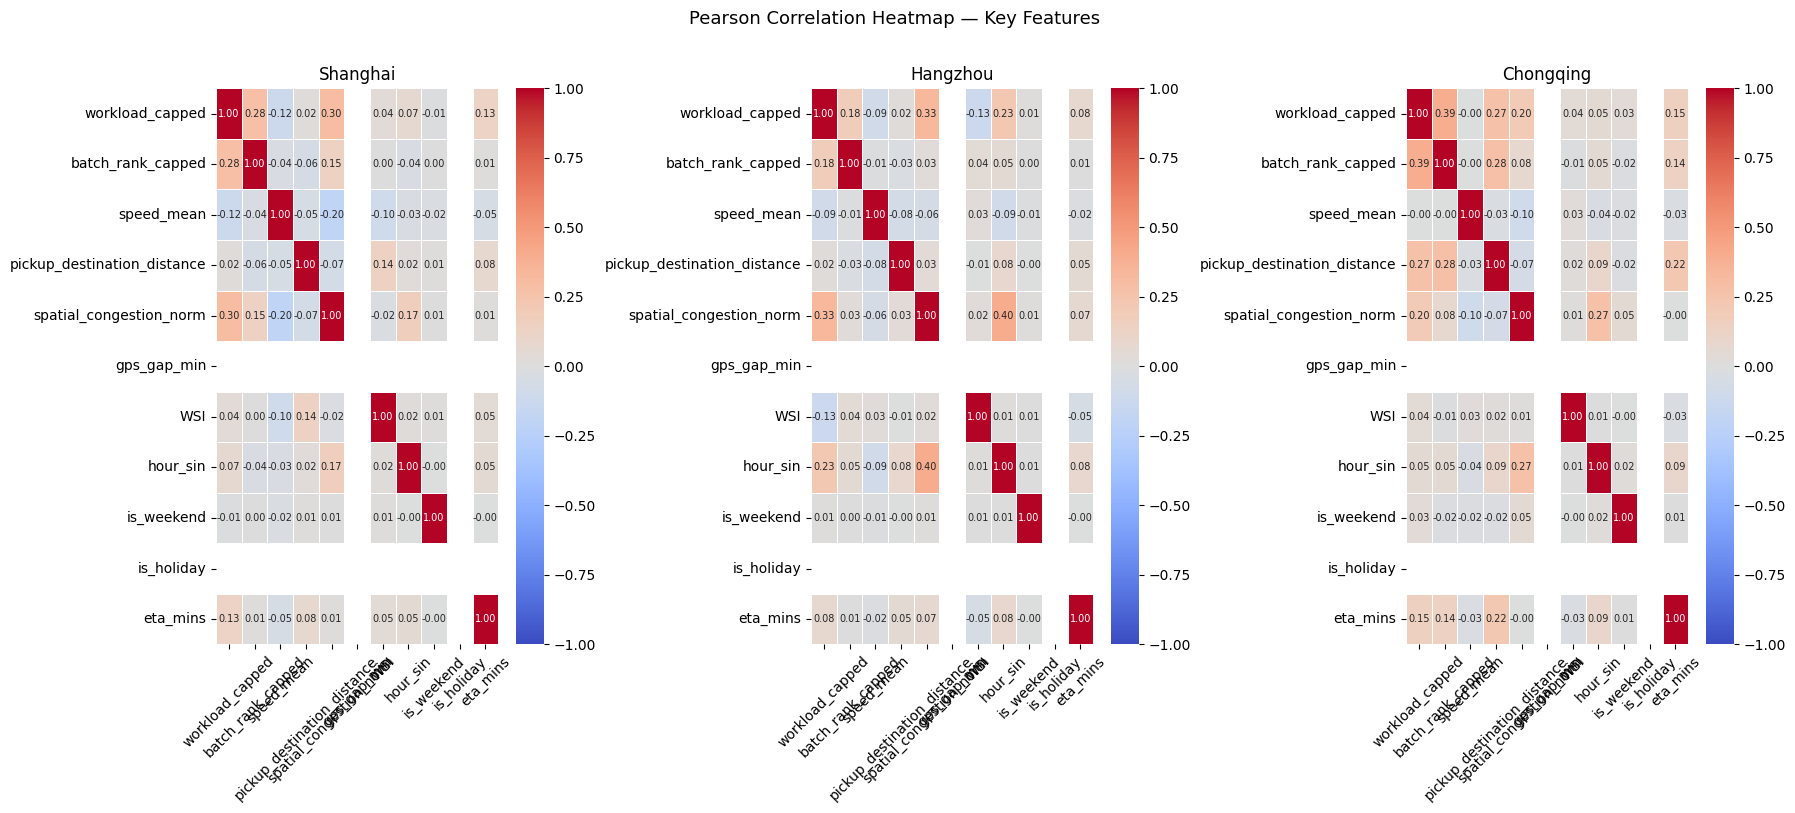

In [29]:
def plot_eta_by_city(city_results: dict, clip_pct: float = 0.95) -> None:
    # ETA KDE overlay for all cities on one axis.
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    for city, df in city_results.items():
        cap  = df["eta_mins"].quantile(clip_pct)
        data = df.filter(pl.col("eta_mins") <= cap)["eta_mins"].to_numpy()
        med  = float(np.median(data))
        sns.kdeplot(data, ax=ax, label=f"{city} (median={med:.0f} min)",
                    color=colors.get(city), fill=True, alpha=0.25)
    ax.set_xlabel("ETA (mins)")
    ax.set_ylabel("Density")
    ax.set_title(f"ETA Distribution by City (<=P{int(clip_pct*100)})")
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_saturation_by_city(city_results: dict) -> None:
    # Workload saturation curves — 1x3 subplot grid.
    fig, axes = plt.subplots(1, len(city_results), figsize=(15, 4), sharey=False)
    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    for ax, (city, df) in zip(axes, city_results.items()):
        plot_df = (
            df.with_columns(pl.col("active_orders_at_receipt_time").clip(upper_bound=20))
            .group_by("active_orders_at_receipt_time")
            .agg(pl.mean("eta_mins").alias("mean_eta"))
            .sort("active_orders_at_receipt_time")
            .to_pandas()
        )
        ax.bar(plot_df["active_orders_at_receipt_time"], plot_df["mean_eta"],
               color=colors.get(city, "steelblue"), alpha=0.8)
        ax.axvline(x=14.5, color="red", linestyle="--", alpha=0.6)
        ax.set_title(city)
        ax.set_xlabel("Active Orders (clipped at 20)")
        ax.set_ylabel("Mean ETA (mins)")
    plt.suptitle("Workload Saturation Curve — All Cities", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_feature_corr_heatmap(city_results: dict) -> None:
    # Side-by-side correlation heatmaps (key features vs eta_mins).
    key_features = [
        "workload_capped", "batch_rank_capped", "speed_mean",
        "pickup_destination_distance", "spatial_congestion_norm",
        "gps_gap_min", "WSI", "hour_sin", "is_weekend", "is_holiday",
        "eta_mins",
    ]
    fig, axes = plt.subplots(1, len(city_results), figsize=(18, 8))
    for ax, (city, df) in zip(axes, city_results.items()):
        avail = [c for c in key_features if c in df.columns]
        corr_mat = df.select(avail).corr().to_pandas()
        corr_mat.columns = avail
        corr_mat.index   = avail
        sns.heatmap(corr_mat, ax=ax, cmap="coolwarm", center=0,
                    annot=True, fmt=".2f", annot_kws={"size": 7},
                    linewidths=0.4, vmin=-1, vmax=1)
        ax.set_title(city)
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)
    plt.suptitle("Pearson Correlation Heatmap — Key Features", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# ── Run cross-city plots ──────────────────────────────────────────────────────
plot_eta_by_city(city_results)
plot_saturation_by_city(city_results)
plot_feature_corr_heatmap(city_results)


## 8. Feature Summary Table

Print a compact summary of all features for each city


In [40]:
import polars as pl

# Using -1 as a sentinel value for missing GPS data
# This allows models to distinguish structural missingness from valid data
for city in city_results:
    city_results[city] = city_results[city].with_columns([
        pl.col("last_x").fill_null(-1.0),
        pl.col("last_y").fill_null(-1.0),
        pl.col("gps_gap_min").fill_null(-1.0)
    ])

# Update the combined dataframe as well
combined = combined.with_columns([
    pl.col("last_x").fill_null(-1.0),
    pl.col("last_y").fill_null(-1.0),
    pl.col("gps_gap_min").fill_null(-1.0)
])

print("Nulls in last_x, last_y, and gps_gap_min have been filled with -1.")
# Verify for one city
print(f"Shanghai nulls after fill: {city_results['Shanghai'].select(['last_x', 'last_y', 'gps_gap_min']).null_count()}")

Nulls in last_x, last_y, and gps_gap_min have been filled with -1.
Shanghai nulls after fill: shape: (1, 3)
┌────────┬────────┬─────────────┐
│ last_x ┆ last_y ┆ gps_gap_min │
│ ---    ┆ ---    ┆ ---         │
│ u32    ┆ u32    ┆ u32         │
╞════════╪════════╪═════════════╡
│ 0      ┆ 0      ┆ 0           │
└────────┴────────┴─────────────┘


In [33]:
# Identify all One-Hot Encoded typecode columns
type_cols = [c for c in combined.columns if 'typecode_grouped_type' in c]

# Fill nulls with 0 for these binary columns
# Since null means that specific city didn't have that OHE category created locally
combined = combined.with_columns([
    pl.col(c).fill_null(0) for c in type_cols
])

print(f"Filled nulls in {len(type_cols)} OHE columns with 0.")
# Verify null counts now
display(combined.select(type_cols).null_count())

Filled nulls in 3 OHE columns with 0.


typecode_grouped_type 1,typecode_grouped_type 2,typecode_grouped_type 3
u32,u32,u32
0,0,0


In [32]:
def feature_summary(city_results: dict) -> None:
    for city, df in city_results.items():
        print(f"\n{'─'*60}")
        print(f"  {city}  |  {df.height:,} rows × {len(df.columns)} cols")
        print(f"{'─'*60}")
        num_cols = [c for c, t in df.schema.items()
                    if isinstance(t, (pl.Float32, pl.Float64, pl.Int8,
                                     pl.Int16, pl.Int32, pl.Int64,
                                     pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64))]
        stats = df.select(num_cols).describe().to_pandas().set_index("statistic")
        eta_row = stats.loc["mean"]
        null_counts = df.select([pl.col(c).null_count().alias(c) for c in num_cols])
        print(f"  eta_mins  mean={df['eta_mins'].mean():.1f}  "
              f"median={df['eta_mins'].median():.1f}  "
              f"p95={df['eta_mins'].quantile(0.95):.1f}")
        for col in sorted(num_cols):
            n_null = null_counts[col].item()
            tag = f"  ⚠ {n_null} nulls" if n_null > 0 else ""
            print(f"  {col:<40}{tag}")

feature_summary(city_results)



────────────────────────────────────────────────────────────
  Shanghai  |  34,735 rows × 76 cols
────────────────────────────────────────────────────────────
  eta_mins  mean=100.3  median=70.0  p95=223.0
  WSI                                     
  active_orders                           
  active_orders_at_receipt_time           
  batch_rank                              
  batch_rank_capped                       
  batch_size                              
  courier_local_load                      
  day_cos                                 
  day_of_week                             
  day_sin                                 
  delivery_sequence                       
  distance_travelled                      
  ds                                      
  environment_id                          
  eta_mins                                
  eta_p33                                 
  eta_p67                                 
  eta_p95                                 
  extreme_batch    

---
# Phase 1 — Invariant Causal Prediction (ICP)


**1. Univariate OLS** — `eta_mins ~ X` alone leaves the ~70-min city mean-shift
(Shanghai vs Chongqing) in the residuals. Levene detects this as variance
heterogeneity for every feature, including genuinely invariant ones.

**2. `city × tier` as environment** — `delivery_tier` is defined by within-city
percentiles of `eta_mins`, so `Shanghai_smooth` and `Chongqing_smooth` have
completely different absolute ETA ranges by construction. Any residual is
guaranteed to be unequal across these environments.

**3. Non-linear data + linear model** — workload has an M/G/1 saturation curve;
OLS misspecification is city-specific because Chongqing reaches workload=68
while Shanghai peaks at 30.

## Two-stage corrected ICP with city-only environments

| Stage | Method | Fixes |
|---|---|---|
| **1** Partial-residual multivariate | Fit OLS on all features jointly; test partial residual `e_X = resid + coef_X·X` | Removes city mean-shift + inter-feature confounding |
| **2** Rank-transformed | Van der Waerden normal scores before Stage 1 | Linearises M/G/1 workload curve and distance thresholds |

**Goals:**
- `INVARIANT` = passes both stages.
- `DIRECTION_STABLE` = fails
invariance tests but sign is consistent across all 3 cities (effect is real,
magnitude city-specific).
- `VARIANT` = sign-inconsistent.

**Environment used: city-only (3)**


The VdW score for the $i$-th observation (after sorting) is defined as:$$y_i = \Phi^{-1}\left( \frac{r_i}{n + 1} \right)$$Where:$r_i$ is the rank of the observation.$n$ is the sample size.$\Phi^{-1}$ is the probit function (inverse of the standard normal CDF).

It maps the data (both features and targets) to a standard normal distribution based on their ranks

In [34]:
!pip install scipy statsmodels --quiet
from scipy.stats import levene, kruskal
import statsmodels.api as sm
import warnings, json as json_lib
warnings.filterwarnings("ignore")
print("scipy + statsmodels ready")

scipy + statsmodels ready


## ICP Step 1 — Environment & Sample Size Check

In [35]:
def icp_sample_size_report(df: pl.DataFrame) -> None:
    """Check all environments have enough samples for ICP and PCMCI+."""
    report = (
        df.group_by(["city", "delivery_tier", "environment"])
        .agg([
            pl.len().alias("n_deliveries"),
            pl.col("delivery_user_id").n_unique().alias("n_couriers"),
            pl.mean("eta_mins").alias("mean_eta"),
        ])
        .with_columns([
            (pl.col("n_deliveries") >= ICP_MIN_ENV_SAMPLES).alias("icp_ok"),
            (pl.col("n_deliveries") >= PCMCI_MIN_SAMPLES).alias("pcmci_ok"),
        ])
        .sort(["city", "delivery_tier"])
    )

    print(f"{'Environment':<30} {'N':>7} {'Couriers':>9} {'MeanETA':>8}  ICP   PCMCI+")
    print("-" * 72)
    for r in report.to_dicts():
        icp_f  = "OK" if r["icp_ok"]   else "FAIL"
        pcm_f  = "OK" if r["pcmci_ok"] else "low"
        print(f"  {r['environment']:<28} {r['n_deliveries']:>7,}"
              f" {r['n_couriers']:>9} {r['mean_eta']:>8.1f}"
              f"  {icp_f:>4}  {pcm_f:>5}")
    print("-" * 72)
    below = report.filter(~pl.col("icp_ok")).height
    print(f"  {'All environments OK' if not below else f'{below} environment(s) below threshold'}")

icp_combined = pl.read_parquet(icp_combined_path)
icp_sample_size_report(combined)


Environment                          N  Couriers  MeanETA  ICP   PCMCI+
------------------------------------------------------------------------
  Chongqing_delayed              8,800       139    670.9    OK     OK
  Chongqing_normal               9,007       139    139.2    OK     OK
  Chongqing_smooth               8,863       141     50.1    OK     OK
  Hangzhou_delayed              13,385       166    316.9    OK     OK
  Hangzhou_normal               13,836       161     92.8    OK     OK
  Hangzhou_smooth               13,523       170     37.9    OK     OK
  Shanghai_delayed              11,331       129    202.0    OK     OK
  Shanghai_normal               11,745       123     71.9    OK     OK
  Shanghai_smooth               11,659       134     30.2    OK     OK
------------------------------------------------------------------------
  All environments OK


## ICP Step 2 — Workload Representation Check

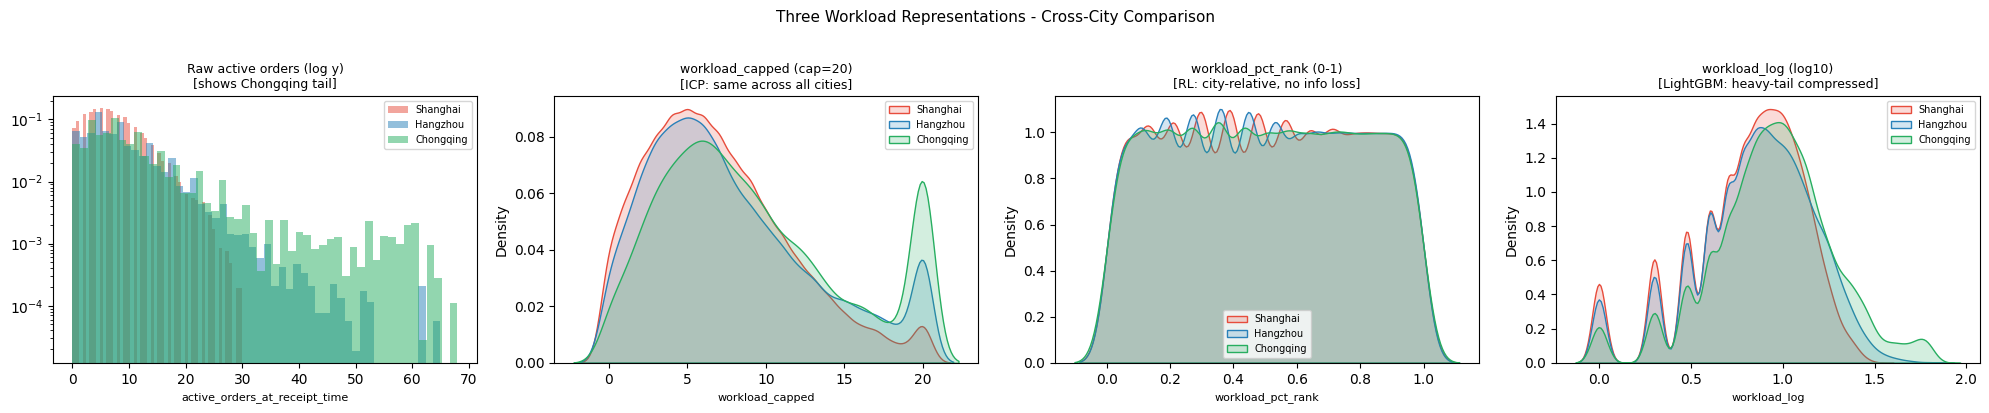

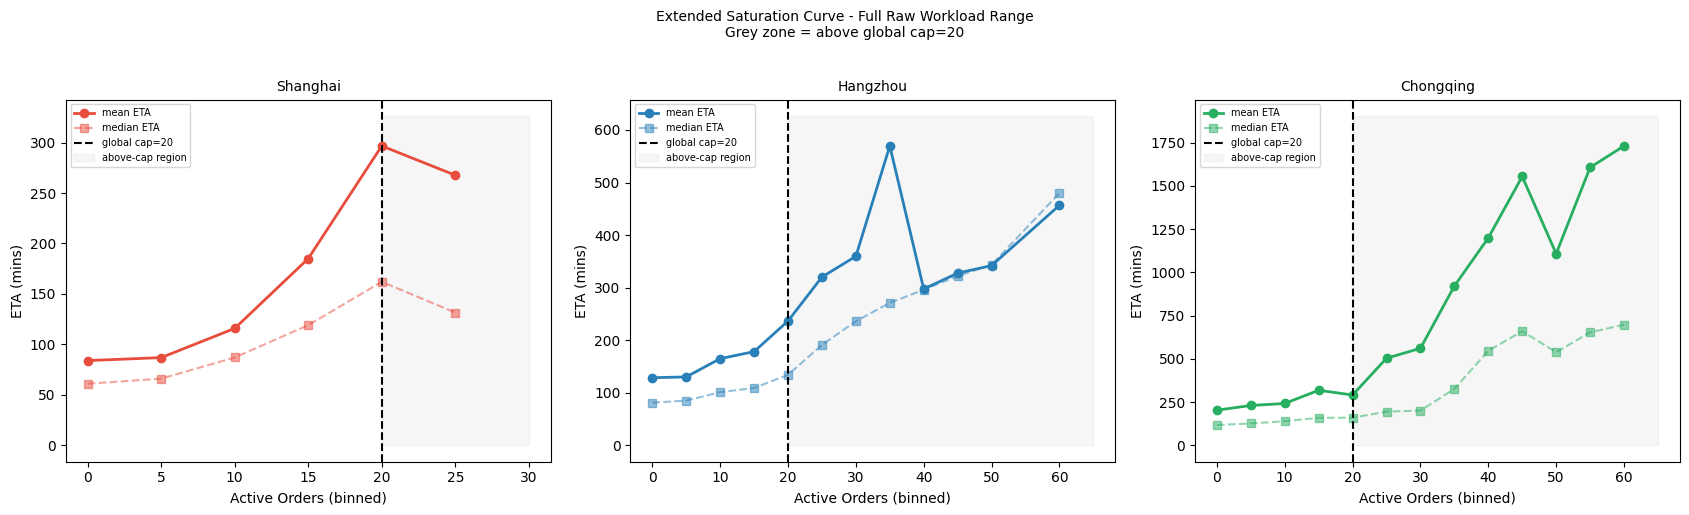

In [36]:
def plot_workload_representations(city_results: dict) -> None:
    """4-panel cross-city comparison of all workload representations."""
    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    panels = [
        ("active_orders_at_receipt_time",
         "Raw active orders (log y)\n[shows Chongqing tail]"),
        ("workload_capped",
         "workload_capped (cap=20)\n[ICP: same across all cities]"),
        ("workload_pct_rank",
         "workload_pct_rank (0-1)\n[RL: city-relative, no info loss]"),
        ("workload_log",
         "workload_log (log10)\n[LightGBM: heavy-tail compressed]"),
    ]

    for ax, (col, title) in zip(axes, panels):
        for city, df in city_results.items():
            if col not in df.columns:
                continue
            data = df[col].drop_nulls().to_numpy()
            if col == "active_orders_at_receipt_time":
                ax.hist(data, bins=50, alpha=0.5, label=city,
                        color=colors[city], density=True)
                ax.set_yscale("log")
            else:
                sns.kdeplot(data, ax=ax, label=city,
                            color=colors[city], fill=True, alpha=0.2)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel(col, fontsize=8)
        ax.legend(fontsize=7)

    plt.suptitle("Three Workload Representations - Cross-City Comparison",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_extended_saturation(city_results: dict, bin_size: int = 5) -> None:
    """
    Mean ETA vs workload bin across the full raw range (no cap applied).
    Answers: does ETA keep rising above 20 in Chongqing?

    Interpretation:
      Flat above 20  -> cap=20 is justified universally
      Rising above 20 -> cap loses signal; use workload_log for tree models
      Falling above 20 -> confounding (experienced couriers self-select high load)
    """
    colors = {"Shanghai": "#e74c3c", "Hangzhou": "#2980b9", "Chongqing": "#27ae60"}
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    for ax, (city, df) in zip(axes, city_results.items()):
        binned = (
            df.with_columns(
                (pl.col("active_orders_at_receipt_time") // bin_size * bin_size)
                .alias("wl_bin")
            )
            .group_by("wl_bin")
            .agg([pl.mean("eta_mins").alias("mean_eta"),
                  pl.median("eta_mins").alias("median_eta"),
                  pl.len().alias("n")])
            .filter(pl.col("n") >= 10)
            .sort("wl_bin").to_pandas()
        )
        ax.plot(binned["wl_bin"], binned["mean_eta"], marker="o",
                color=colors[city], label="mean ETA", linewidth=2)
        ax.plot(binned["wl_bin"], binned["median_eta"], marker="s",
                color=colors[city], alpha=0.5, linestyle="--", label="median ETA")
        ax.axvline(x=20, color="black", linestyle="--", linewidth=1.5,
                   label="global cap=20")
        ax.fill_betweenx(
            [0, binned["mean_eta"].max() * 1.1],
            20, binned["wl_bin"].max() + bin_size,
            alpha=0.07, color="grey", label="above-cap region"
        )
        ax.set_title(city, fontsize=10)
        ax.set_xlabel("Active Orders (binned)")
        ax.set_ylabel("ETA (mins)")
        ax.legend(fontsize=7)

    plt.suptitle(
        "Extended Saturation Curve - Full Raw Workload Range\n"
        "Grey zone = above global cap=20",
        fontsize=10, y=1.02)
    plt.tight_layout()
    plt.show()

plot_workload_representations(city_results)
plot_extended_saturation(city_results)

## ICP Step 3 — Two-Stage Invariance Tests

In [41]:
ICP_CANDIDATE_FEATURES = [
    "workload_capped", "high_load", "overloaded",
    "batch_rank_capped", "batch_size", "late_batch",
    "pickup_destination_distance",
    "speed_mean", "distance_travelled", "gps_points", "is_trajectory_available",
    "delivery_sequence",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "is_weekend", "is_holiday",
    "spatial_congestion_norm", "courier_local_load",
    "WSI", "precipitation", "temperature_2m",
    "typecode_grouped_type 1", "typecode_grouped_type 2",
    "typecode_grouped_type 3",
]

# ── helpers ───────────────────────────────────────────────────────────────────
def _valid_feats(df, cands):
    return [f for f in cands if f in df.columns and df[f].notna().sum() > 50]

def _inv_test(groups, alpha=ICP_ALPHA):
    if len(groups) < 2:
        return 0.0, 0.0, False
    lev_p = levene(*groups).pvalue
    kw_p  = kruskal(*groups).pvalue
    return round(lev_p, 4), round(kw_p, 4), (lev_p >= alpha) and (kw_p >= alpha)

def _env_groups(df, resid_col, env_col, min_n=30):
    return [df.loc[df[env_col] == e, resid_col].dropna().values
            for e in sorted(df[env_col].unique())
            if (df[env_col] == e).sum() >= min_n]

def _normal_scores(s):
    r = s.rank()
    return r.apply(lambda v: ndtri(v / (len(s) + 1)))


# ── Stage 1: partial-residual multivariate ICP ────────────────────────────────
def run_partial_icp(df, cands, target="eta_mins", env_col="city", alpha=ICP_ALPHA):
    """
    Fit multivariate OLS with all candidate features jointly.
    For each feature X compute partial residual:  e_X = resid + coef_X * X
    Test e_X across city-only environments (Levene + Kruskal-Wallis).

    Why this fixes the original all-variant result:
    - multivariate OLS removes inter-feature confounding
    - partial residual removes the city mean-shift from the test
    - city-only environments remove the tier-target circularity
    """
    feats = _valid_feats(df, cands)
    sub   = df[feats + [target, env_col]].dropna()
    try:
        model = sm.OLS(sub[target], sm.add_constant(sub[feats])).fit()
    except Exception as e:
        print(f"OLS failed: {e}")
        return {}

    results = {}
    for feat in feats:
        coef = float(model.params.get(feat, float("nan")))
        se   = float(model.bse.get(feat,   float("nan")))
        pval = float(model.pvalues.get(feat, 1.0))

        pr     = model.resid + coef * sub[feat]
        sub_r  = sub[[env_col]].copy()
        sub_r["pr"] = pr.values
        groups = _env_groups(sub_r, "pr", env_col)
        lev_p, kw_p, inv = _inv_test(groups, alpha)

        per_env = {}
        for e in sorted(df[env_col].unique()):
            es = sub[sub[env_col] == e]
            if len(es) < 20:
                continue
            try:
                m = sm.OLS(es[target], sm.add_constant(es[feats])).fit()
                per_env[e] = round(float(m.params.get(feat, float("nan"))), 4)
            except Exception:
                pass

        sign_stable = (
            all(v > 0 for v in per_env.values()) or
            all(v < 0 for v in per_env.values())
        ) if per_env else False

        results[feat] = dict(
            stage1_inv=inv,
            stage1_lev_p=lev_p,
            stage1_kw_p=kw_p,
            ols_coef=round(coef, 4),
            ols_se=round(se, 4),
            ols_pval=round(pval, 4),
            per_env_coef=per_env,
            sign_stable=sign_stable,
        )
    return results


# ── Stage 2: rank-transformed ICP ─────────────────────────────────────────────
def run_rank_icp(df, cands, target="eta_mins", env_col="city", alpha=ICP_ALPHA):
    """
    Van der Waerden normal-score transform on target + features, then Stage 1.
    Linearises monotone non-linearities (workload saturation, distance thresholds)
    without assuming a functional form.
    """
    feats = _valid_feats(df, cands)
    sub   = df[feats + [target, env_col]].dropna().copy()
    sub[target] = _normal_scores(sub[target])
    for f in feats:
        try:
            sub[f] = _normal_scores(sub[f].astype(float))
        except Exception:
            pass
    try:
        model = sm.OLS(sub[target], sm.add_constant(sub[feats])).fit()
    except Exception as e:
        print(f"Rank OLS failed: {e}")
        return {}

    results = {}
    for feat in feats:
        coef   = float(model.params.get(feat, float("nan")))
        pr     = model.resid + coef * sub[feat]
        sub_r  = sub[[env_col]].copy()
        sub_r["pr"] = pr.values
        groups = _env_groups(sub_r, "pr", env_col)
        lev_p, kw_p, inv = _inv_test(groups, alpha)
        results[feat] = dict(
            stage2_inv=inv,
            stage2_lev_p=round(lev_p, 4),
            stage2_kw_p=round(kw_p, 4),
        )
    return results


# ── Run both stages ───────────────────────────────────────────────────────────
icp_pd = icp_combined.to_pandas()
print(f"ICP dataset  : {len(icp_pd):,} rows | "
      f"{icp_pd['city'].nunique()} city environments (was 9 city×tier) | "
      f"{len(ICP_CANDIDATE_FEATURES)} candidates\n")

print("Stage 1: partial-residual multivariate OLS ...")
s1 = run_partial_icp(icp_pd, ICP_CANDIDATE_FEATURES)
print(f"  done — {sum(r['stage1_inv'] for r in s1.values())} pass Stage 1")

print("Stage 2: rank-transformed OLS ...")
s2 = run_rank_icp(icp_pd, ICP_CANDIDATE_FEATURES)
print(f"  done — {sum(r['stage2_inv'] for r in s2.values())} pass Stage 2\n")


ICP dataset  : 102,149 rows | 3 city environments (was 9 city×tier) | 26 candidates

Stage 1: partial-residual multivariate OLS ...
  done — 0 pass Stage 1
Stage 2: rank-transformed OLS ...
  done — 0 pass Stage 2



## ICP Step 4 — Consensus Results

In [43]:
def build_consensus(s1, s2, feats):
    consensus = {}
    for feat in feats:
        r1 = s1.get(feat, {})
        r2 = s2.get(feat, {})
        inv1  = r1.get("stage1_inv", False)
        inv2  = r2.get("stage2_inv", False)
        sign  = r1.get("sign_stable", False)

        if inv1 and inv2:
            verdict = "INVARIANT"
        elif sign:
            verdict = "DIRECTION_STABLE"
        else:
            verdict = "VARIANT"

        consensus[feat] = dict(
            verdict=verdict,
            inv1=inv1, inv2=inv2,
            lev1=r1.get("stage1_lev_p", 0.0),
            kw1=r1.get("stage1_kw_p", 0.0),
            lev2=r2.get("stage2_lev_p", 0.0),
            coef=r1.get("ols_coef", float("nan")),
            per_env=r1.get("per_env_coef", {}),
            sign_stable=sign,
        )
    return consensus


def display_consensus(c):
    order = ["INVARIANT", "DIRECTION_STABLE", "VARIANT"]
    rows  = sorted(c.items(),
                   key=lambda x: (order.index(x[1]["verdict"]), -x[1]["lev1"]))

    hdr = (f"  {'Feature':<36} {'Verdict':<18} "
           f"{'S1_Lev_p':>9} {'S2_Lev_p':>9} {'Coef':>8}  CoefRange")
    print(hdr)
    print("-" * len(hdr))
    for feat, r in rows:
        pe  = r["per_env"]
        rng = (f"[{min(pe.values()):+.3f},{max(pe.values()):+.3f}]"
               if pe else "n/a")
        star = {"INVARIANT": "***", "DIRECTION_STABLE": "** ", "VARIANT": "   "}[r["verdict"]]
        print(f"  {star} {feat:<33} {r['verdict']:<18} "
              f"{r['lev1']:>9.4f} {r['lev2']:>9.4f} {r['coef']:>8.4f}  {rng}")
    print("-" * len(hdr))

    inv = [f for f, r in rows if r["verdict"] == "INVARIANT"]
    ds  = [f for f, r in rows if r["verdict"] == "DIRECTION_STABLE"]
    var = [f for f, r in rows if r["verdict"] == "VARIANT"]
    print(f"\n*** INVARIANT ({len(inv)}): {inv}")
    print(f"**  DIRECTION_STABLE ({len(ds)}): {ds}")
    print(f"    VARIANT ({len(var)}): {var}")
    return inv, ds, var


consensus = build_consensus(s1, s2, ICP_CANDIDATE_FEATURES)
invariant_features, direction_stable, variant_features = display_consensus(consensus)


  Feature                              Verdict             S1_Lev_p  S2_Lev_p     Coef  CoefRange
-------------------------------------------------------------------------------------------------
  **  overloaded                        DIRECTION_STABLE      0.0000    0.0000 109.5266  [+25.441,+83.009]
  **  pickup_destination_distance       DIRECTION_STABLE      0.0000    0.0000   0.0142  [+0.004,+0.035]
  **  delivery_sequence                 DIRECTION_STABLE      0.0000    0.0000  -0.1355  [-0.161,-0.035]
  **  hour_sin                          DIRECTION_STABLE      0.0000    0.0000  25.5183  [+9.118,+40.712]
  **  spatial_congestion_norm           DIRECTION_STABLE      0.0000    0.0000 -25.6306  [-40.108,-0.168]
  **  courier_local_load                DIRECTION_STABLE      0.0000    0.0000   6.8302  [+2.883,+11.271]
  **  typecode_grouped_type 1           DIRECTION_STABLE      0.0000    0.0000 -28.2875  [-32.549,-16.668]
  **  typecode_grouped_type 2           DIRECTION_STABLE      

## ICP Step 5 — Coefficient Stability Plot

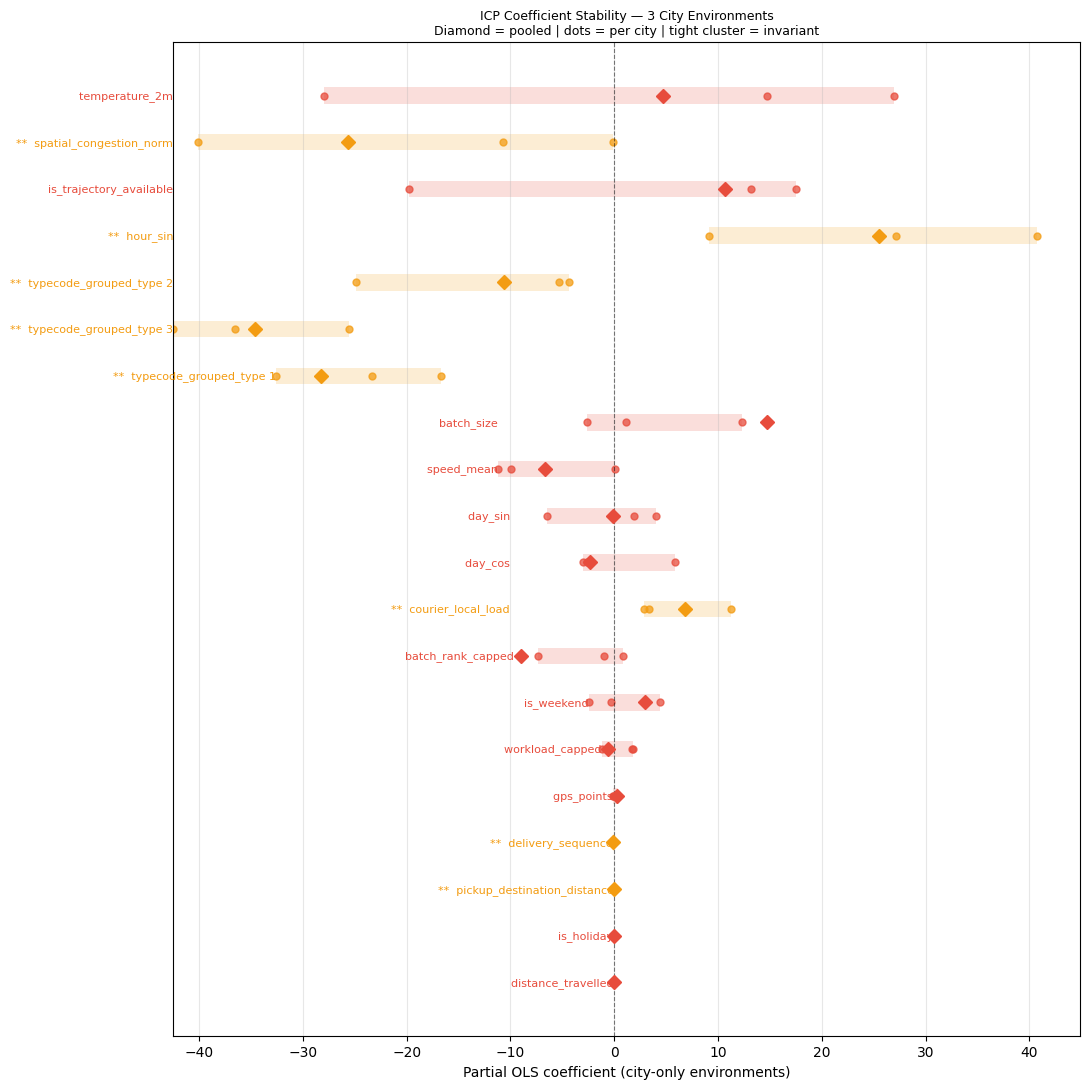

In [44]:
def plot_coef_stability(consensus, top_n=20):
    """
    Dot-and-range chart: each dot = one city's partial OLS coefficient.
    Diamond = pooled coefficient.
    Tight cluster = invariant. Wide spread or sign flip = variant.
    """
    rows = [(f, r) for f, r in consensus.items() if r["per_env"]]
    rows.sort(key=lambda x: abs(
        max(x[1]["per_env"].values()) - min(x[1]["per_env"].values())
    ))
    rows = rows[:top_n]

    colors = {
        "INVARIANT":       "#27ae60",
        "DIRECTION_STABLE":"#f39c12",
        "VARIANT":         "#e74c3c",
    }
    fig, ax = plt.subplots(figsize=(11, max(5, len(rows) * 0.55)))

    for i, (feat, r) in enumerate(rows):
        c     = colors[r["verdict"]]
        coefs = list(r["per_env"].values())
        ax.barh(i, max(coefs) - min(coefs), left=min(coefs),
                height=0.35, color=c, alpha=0.18)
        for v in coefs:
            ax.plot(v, i, "o", color=c, ms=5, alpha=0.75)
        ax.plot(r["coef"], i, "D", color=c, ms=7, zorder=5)
        star = {"INVARIANT": "***", "DIRECTION_STABLE": "** ", "VARIANT": "   "}[r["verdict"]]
        ax.text(ax.get_xlim()[0] - 0.001, i,
                f"{star} {feat}", va="center", ha="right",
                fontsize=8, color=c)

    ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.5)
    ax.set_yticks([])
    ax.set_xlabel("Partial OLS coefficient (city-only environments)")
    ax.set_title(
        "ICP Coefficient Stability — 3 City Environments\n"
        "Diamond = pooled | dots = per city | tight cluster = invariant",
        fontsize=9,
    )
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_coef_stability(consensus)


## ICP Step 6 — Save

In [45]:
import os

results_path = os.path.join(ICP_DIR, "icp_phase1_results.json")
with open(results_path, "w") as f:
    json_lib.dump(
        {"stage1": s1, "stage2": s2, "consensus": consensus},
        f, indent=2, default=str,
    )
print(f"Results  -> {results_path}")

summary = {
    "alpha": ICP_ALPHA,
    "n_environments": 3,
    "environments": sorted(icp_pd["city"].unique().tolist()),
    "n_candidates": len(ICP_CANDIDATE_FEATURES),
    "invariant_features": invariant_features,
    "direction_stable": direction_stable,
    "variant_features": variant_features,
    "pcmci_candidates": invariant_features + direction_stable,
    "irm_features": variant_features,
    "note": (
        "INVARIANT: passes partial-residual OLS AND rank-transformed OLS "
        "across 3 city-only environments. "
        "DIRECTION_STABLE: fails invariance tests but coefficient sign is "
        "consistent across all 3 cities — effect is real, magnitude city-specific. "
        "VARIANT: sign-inconsistent across cities."
    ),
}
summary_path = os.path.join(ICP_DIR, "icp_phase1_summary.json")
with open(summary_path, "w") as f:
    json_lib.dump(summary, f, indent=2)
print(f"Summary  -> {summary_path}")

print(f"""
ICP Phase 1 Complete
  Method          : partial-residual multivariate + rank-transform
  Environments    : city-only (3)  [not city x tier]
  Invariant       : {len(invariant_features)}  -> PCMCI+ causal edges
  Direction-stable: {len(direction_stable)}  -> PCMCI+ conditional parents
  Variant         : {len(variant_features)}  -> IRM domain-generalisation features

Load in PCMCI+ notebook:
  with open('icp_phase1_summary.json') as f:
      s = json.load(f)
  pcmci_features = s['pcmci_candidates']
  irm_features   = s['irm_features']
""")


Results  -> /content/drive/MyDrive/ml/PROCESSED/icp/icp_phase1_results.json
Summary  -> /content/drive/MyDrive/ml/PROCESSED/icp/icp_phase1_summary.json

ICP Phase 1 Complete
  Method          : partial-residual multivariate + rank-transform
  Environments    : city-only (3)  [not city x tier]
  Invariant       : 0  -> PCMCI+ causal edges
  Direction-stable: 9  -> PCMCI+ conditional parents
  Variant         : 17  -> IRM domain-generalisation features

Load in PCMCI+ notebook:
  with open('icp_phase1_summary.json') as f:
      s = json.load(f)
  pcmci_features = s['pcmci_candidates']
  irm_features   = s['irm_features']



---
# Phase 2 — Invariant Risk Minimisation (IRM)

## What was wrong with the previous IRM run

| Issue | Previous | Fixed |
|---|---|---|
| Environments | 9 (city×tier) | 3 (city-only) |
| Feature scaling | None | `StandardScaler` (fit on train split only) |
| Epochs | 100 | 500 |
| λ schedule | Fixed at 10 | Anneal 1 → 100 over first 100 epochs |
| Minibatches | Full data per step | 512-sample random batches |

The 9-environment setup gave IRM 6 Shanghai/Hangzhou groups vs 3 Chongqing
groups. The invariance penalty then down-weighted Chongqing's gradient simply
from imbalance — not genuine invariance pressure. That is why Chongqing OOD
performance was -24%/-28% worse under IRM: IRM was penalising the most
Chongqing-specific signal (correctly), but also pushing the model away from
features that would have helped it generalise there.

**The corrected run** uses city-only (3) environments so each city gets equal
weight in the invariance penalty, with proper feature normalisation and enough
epochs for λ warmup to stabilise the representation.


In [46]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Feature set: ICP candidates + direction-stable (exclude metadata + target)
_exclude = {'order_id', 'city', 'delivery_tier', 'environment',
            'from_dipan_id', 'ds', 'from_city_en', 'weather_time',
            'time_window', 'eta_mins'}

irm_feature_cols = [
    f for f in (invariant_features + direction_stable)
    if f in combined.columns and f not in _exclude
]

# Fill structural-missingness zeros (GPS absent = 0, not noise)
irm_df = (combined
          .select(irm_feature_cols + ['eta_mins', 'city'])
          .fill_null(0)
          .to_pandas())

print(f"IRM features  : {len(irm_feature_cols)}")
print(f"IRM dataset   : {len(irm_df):,} rows | 3 city environments")
print(f"Features      : {irm_feature_cols}")


IRM features  : 9
IRM dataset   : 102,149 rows | 3 city environments
Features      : ['overloaded', 'pickup_destination_distance', 'delivery_sequence', 'hour_sin', 'spatial_congestion_norm', 'courier_local_load', 'typecode_grouped_type 1', 'typecode_grouped_type 2', 'typecode_grouped_type 3']


In [47]:
# Standard MLP -> 3 hidden layers 128,64 and 32 neurons
# ReLu + 10 pc dropout

class IRM_MLP(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 64),  nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64,  32),  nn.ReLU(),
            nn.Linear(32,  1),
        )

    def forward(self, x):
        return self.net(x)


#
def irm_penalty(logits, y):
    """IRMv1: squared gradient of loss w.r.t. a dummy scalar = 1.0."""

    #  In IRM, we want the relationship the model learned to be 'perfect' for Shanghai, Hangzhou, and
    #  Chongqing simultaneously.
    #
    # We multiply the model's predictions by this scalar (initially 1.0).
    # We calculate the loss (MSE).
    # We check the gradient (slope) of that loss with respect to the scalar.
    # If the gradient is 0, it means the model is already perfectly calibrated for that specific city—no scaling up or down is needed to improve the prediction.
    scale = torch.tensor(1.).requires_grad_(True)
    loss  = F.mse_loss(logits * scale, y)
    grad  = torch.autograd.grad(loss, [scale], create_graph=True)[0]
    return torch.sum(grad ** 2)


print("IRM_MLP and irm_penalty defined.")


IRM_MLP and irm_penalty defined.


In [48]:
# -------------------------------------------------
# IRM - training and eval loop
# ------------------------------------------------

"""

This cell performs the actual IRM training and evaluation using a 'Leave-One-City-Out' strategy.

Step-by-step breakdown:

- Leave-One-City-Out Loop: It iterates through the three cities (Shanghai, Hangzhou, Chongqing).
                          In each iteration, it hides one city as the 'test set' and trains the model on the remaining two.

- Standardization: For each fold, it fits a StandardScaler on the training cities and applies it to the test city
                  to ensure the neural network receives normalized data.

- The Dual Model setup: For comparison, it initializes two models: an IRM model (which uses the invariance penalty)
       and an ERM model (standard training without the penalty).
      This allows us to measure if IRM actually helps generalization.

- Lambda Annealing: The code uses a 'warmup' for the IRM penalty (λ). It starts with a low penalty and gradually
  increases it to 100.0. This helps the model find a good predictive baseline before forcing
   the strict invariance constraint.

- Environment Batching: In the inner training loop, it samples minibatches from each training city separately.
    It calculates the loss and the IRM penalty for each city, then averages them.
    This ensures each 'environment' (city) has an equal vote in the training process.

Evaluation: Finally, it calculates the Mean Absolute Error (MAE) on the unseen city, allowing us to see
    which city is the hardest to generalize to.


"""


CITIES          = ['Shanghai', 'Hangzhou', 'Chongqing']
EPOCHS          = 500
LR              = 1e-3
BATCH           = 512
LAM_MAX         = 100.0   # final lambda
LAM_WARMUP      = 100     # epochs to ramp 1 -> LAM_MAX

results_irm = []

for test_city in CITIES:
    print(f"\n>>> Held-out: {test_city}")

    train_df = irm_df[irm_df['city'] != test_city].copy()
    test_df  = irm_df[irm_df['city'] == test_city].copy()

    # Scale on training data only
    scaler  = StandardScaler()

    X_train = scaler.fit_transform(
        train_df[irm_feature_cols].values).astype("float32")
    y_train = train_df['eta_mins'].values.astype("float32").reshape(-1, 1)

    X_test  = scaler.transform(
        test_df[irm_feature_cols].values).astype("float32")

    y_test  = test_df['eta_mins'].values.astype("float32").reshape(-1, 1)

    # ----------------------------------------------------------------

    # Per-city tensors from training set  (city-only environments)
    train_cities  = [c for c in CITIES if c != test_city]
    city_tensors  = {}
    for c in train_cities:
        mask = train_df['city'].values == c
        city_tensors[c] = (
            torch.tensor(X_train[mask]),
            torch.tensor(y_train[mask]),
        )

    n_feat    = X_train.shape[1]
    irm_model = IRM_MLP(n_feat)
    erm_model = IRM_MLP(n_feat)

    # adam optimiser
    irm_opt   = optim.Adam(irm_model.parameters(), lr=LR)
    erm_opt   = optim.Adam(erm_model.parameters(), lr=LR)

    for epoch in range(EPOCHS):
        irm_model.train()
        erm_model.train()

        # Lambda annealing:
        #  We start with λ=1 and gradually increase it to 100 over the first 100 epochs (LAM_WARMUP).
        # This allows the model to first find features that are generally useful for predicting ETA
        lam = min(LAM_MAX, 1.0 + (LAM_MAX - 1.0) * epoch / LAM_WARMUP)

        irm_erm = 0.0
        irm_pen = 0.0
        erm_tot = 0.0

        for c, (Xc, yc) in city_tensors.items():
            idx = torch.randperm(len(Xc))[:BATCH]    # pickout rando batch of deliveries 512
            xb, yb = Xc[idx], yc[idx]

            out_irm   = irm_model(xb)
            irm_erm  += F.mse_loss(out_irm, yb)           # calculates the standard Mean Squared Error
            irm_pen  += irm_penalty(out_irm, yb)          # irm_penalty function to check if the model is cheating by using city-specific shortcuts.

            erm_tot  += F.mse_loss(erm_model(xb), yb)

        n_env = len(train_cities)
        loss_irm = irm_erm / n_env + lam * irm_pen / n_env     # It takes the average error across all cities & adds the averaged penalty multiplied by Lambda
        irm_opt.zero_grad()
        loss_irm.backward()
        irm_opt.step()
        # backprop
        erm_opt.zero_grad()
        (erm_tot / n_env).backward()
        erm_opt.step()

    # Evaluate on held-out city
    irm_model.eval()
    erm_model.eval()
    Xt = torch.tensor(X_test)
    with torch.no_grad():
        irm_p = irm_model(Xt).numpy()
        erm_p = erm_model(Xt).numpy()

    irm_mae  = mean_absolute_error(y_test, irm_p)
    irm_rmse = np.sqrt(mean_squared_error(y_test, irm_p))
    erm_mae  = mean_absolute_error(y_test, erm_p)
    erm_rmse = np.sqrt(mean_squared_error(y_test, erm_p))
    delta    = erm_mae - irm_mae
    pct      = delta / erm_mae * 100

    print(f"  IRM MAE={irm_mae:.1f}  ERM MAE={erm_mae:.1f}  "
          f"delta={delta:+.1f} min  ({pct:+.1f}%)")

    results_irm.append(dict(
        city=test_city,
        IRM_MAE=irm_mae, IRM_RMSE=irm_rmse,
        ERM_MAE=erm_mae, ERM_RMSE=erm_rmse,
        delta_mae=delta, pct_improvement=pct,
    ))

results_df = pd.DataFrame(results_irm)
print("\n--- Leave-One-City-Out Summary ---")
print(results_df[['city', 'IRM_MAE', 'ERM_MAE', 'delta_mae', 'pct_improvement']]
      .to_string(index=False))



>>> Held-out: Shanghai
  IRM MAE=100.3  ERM MAE=101.7  delta=+1.4 min  (+1.4%)

>>> Held-out: Hangzhou
  IRM MAE=148.2  ERM MAE=144.0  delta=-4.2 min  (-2.9%)

>>> Held-out: Chongqing
  IRM MAE=285.0  ERM MAE=206.9  delta=-78.1 min  (-37.8%)

--- Leave-One-City-Out Summary ---
     city    IRM_MAE    ERM_MAE  delta_mae  pct_improvement
 Shanghai 100.323708 101.722755   1.399048         1.375354
 Hangzhou 148.181641 143.956284  -4.225357        -2.935167
Chongqing 285.014496 206.883713 -78.130783       -37.765555


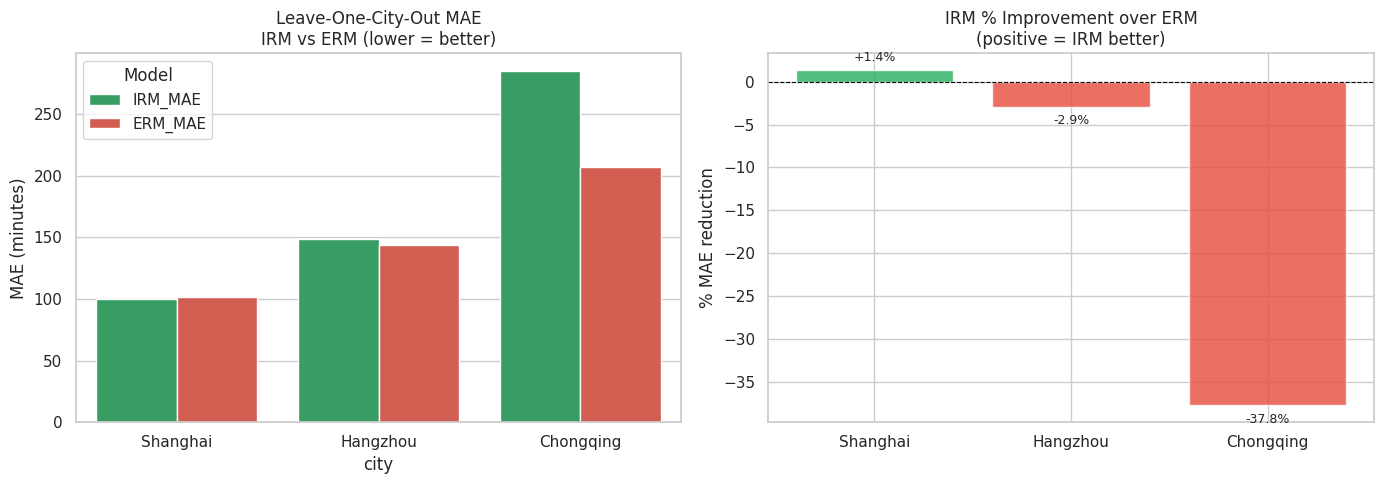

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mae_melt = results_df.melt(
    id_vars='city', value_vars=['IRM_MAE', 'ERM_MAE'],
    var_name='Model', value_name='MAE')
sns.barplot(ax=axes[0], data=mae_melt, x='city', y='MAE', hue='Model',
            palette={'IRM_MAE': '#27ae60', 'ERM_MAE': '#e74c3c'})
axes[0].set_title('Leave-One-City-Out MAE\nIRM vs ERM (lower = better)')
axes[0].set_ylabel('MAE (minutes)')

bar_colors = ['#27ae60' if v >= 0 else '#e74c3c'
              for v in results_df['pct_improvement']]
axes[1].bar(results_df['city'], results_df['pct_improvement'],
            color=bar_colors, alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_title('IRM % Improvement over ERM\n(positive = IRM better)')
axes[1].set_ylabel('% MAE reduction')
for i, (_, row) in enumerate(results_df.iterrows()):
    ypos = row['pct_improvement'] + (1 if row['pct_improvement'] >= 0 else -2)
    axes[1].text(i, ypos, f"{row['pct_improvement']:+.1f}%",
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [51]:
import os
import json as json_lib

irm_summary = {
    "n_features": len(irm_feature_cols),
    "features": irm_feature_cols,
    "environments": "city-only (3)",
    "epochs": EPOCHS,
    "lambda_max": LAM_MAX,
    "lambda_warmup_epochs": LAM_WARMUP,
    "batch_size": BATCH,
    "results": results_df.to_dict(orient="records"),
    "notes": (
        "City-only environments (not city x tier). "
        "StandardScaler fitted on training set only. "
        "Lambda annealing 1->100 over 100 epochs, then fixed at 100. "
        "500 total epochs, 512-sample minibatches. "
        "Leave-one-city-out evaluation."
    ),
}
path = os.path.join(ICP_DIR, "irm_results.json")
with open(path, "w") as f:
    json_lib.dump(irm_summary, f, indent=2, default=str)
print(f"IRM results -> {path}")


IRM results -> /content/drive/MyDrive/ml/PROCESSED/icp/irm_results.json
